# FASE 3 — Feature Engineering: Lag y Adstock
## K-Moda Marketing Mix Modeling · Trabajo IA (UAX)

**Input:** `data/df_ventas_clean.parquet` y `data/df_inversion_clean.parquet` (Fase 1)  
**Output:** `data/df_model.parquet` — dataset listo para entrenar el modelo

### Transformaciones implementadas

**1 — Lag temporal:**
$$X'_{t,m} = X_{t-L_m,\,m}$$
La publicidad no impacta instantáneamente: un anuncio de radio de esta semana genera ventas la semana siguiente ($L=1$). Paid Search sí es inmediato ($L=0$).

**2 — Adstock geométrico:**
$$A_{t,m} = X'_{t,m} + \alpha_m \cdot A_{t-1,\,m}$$
La memoria publicitaria decae semana a semana. Una valla exterior ($\alpha=0.7$) retiene el 70% de su impacto cada semana; un email ($\alpha=0.2$) solo el 20%.

| Canal | Lag (sem) | $\alpha$ | Justificación |
|-------|-----------|----------|---------------|
| Paid Search | 0 | 0.30 | Intención inmediata, decay rápido |
| Social Paid | 1 | 0.50 | Efecto social medio |
| Video Online | 1 | 0.60 | Branding, más persistencia |
| Display | 0 | 0.40 | Retargeting, decay moderado |
| Email CRM | 0 | 0.20 | Impacto inmediato y breve |
| Radio Local | 1 | 0.50 | Offline, lag mayor |
| Exterior | 1 | 0.25 | Vallas, máxima persistencia |
| Prensa | 1 | 0.40 | Offline moderado |

In [82]:
# ============================================================
# CELDA 1 — IMPORTS Y CONFIGURACIÓN
# ============================================================
import os
import re
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns

warnings.filterwarnings('ignore')

GOLD    = '#C9A84C'
BLACK   = '#1A1A1A'
CREAM   = '#F5F0E8'
DARK    = '#2C2C2C'
GRAY    = '#8C8C8C'
RED_    = '#C0392B'
GREEN_  = '#27AE60'
BLUE_   = '#2980B9'
TEAL_   = '#16A085'
ORANGE_ = '#E67E22'
PURPLE_ = '#8E44AD'

COLORS = [
    GOLD, '#5B4A2E', '#8B7355', '#D4B896',
    '#A0856C', '#E8D5B7', '#6B5344', '#9B8B77',
    '#C4A882', '#7A6654',
]
CANAL_COLORS = {
    'Paid Search' : GOLD,
    'Social Paid' : BLUE_,
    'Video Online': TEAL_,
    'Display'     : ORANGE_,
    'Email CRM'   : PURPLE_,
    'Radio Local' : RED_,
    'Exterior'    : GREEN_,
    'Prensa'      : DARK,
}

plt.rcParams.update({
    'figure.facecolor' : CREAM,
    'axes.facecolor'   : CREAM,
    'axes.edgecolor'   : BLACK,
    'axes.labelcolor'  : BLACK,
    'xtick.color'      : BLACK,
    'ytick.color'      : BLACK,
    'text.color'       : BLACK,
    'font.family'      : 'sans-serif',
    'axes.titlesize'   : 13,
    'axes.labelsize'   : 11,
    'legend.fontsize'  : 10,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})

PROJECT_DIR = os.path.dirname(os.path.abspath('03_feature_engineering.ipynb'))
IMG_DIR     = os.path.join(PROJECT_DIR, 'img')
DATA_DIR    = os.path.join(PROJECT_DIR, 'data')
os.makedirs(IMG_DIR, exist_ok=True)

def guardar_img(nombre, fig=None, dpi=150):
    pattern = re.compile(rf'^{re.escape(nombre)}_v(\d+)\.png$')
    existing = [int(m.group(1)) for f in os.listdir(IMG_DIR) if (m := pattern.match(f))]
    v = max(existing) + 1 if existing else 1
    ruta = os.path.join(IMG_DIR, f'{nombre}_v{v:03d}.png')
    (fig or plt.gcf()).savefig(ruta, dpi=dpi, bbox_inches='tight', facecolor=CREAM)
    print(f'  → img/{nombre}_v{v:03d}.png')
    return ruta

print('✓ Setup listo')

✓ Setup listo


In [83]:
# ============================================================
# CELDA 2 — CARGA DE PARQUETS (outputs Fase 1)
# ============================================================
df_ventas = pd.read_parquet(os.path.join(DATA_DIR, 'df_ventas_clean.parquet'))
df_inv    = pd.read_parquet(os.path.join(DATA_DIR, 'df_inversion_clean.parquet'))

# Asegurar orden cronológico
df_ventas = df_ventas.sort_values('semana_dt').reset_index(drop=True)
df_inv    = df_inv.sort_values('semana_dt').reset_index(drop=True)

CANALES = ['Paid Search','Social Paid','Video Online','Display',
           'Email CRM','Radio Local','Exterior','Prensa']

EXOG_COLS = [
    'payday_flag', 'rebajas_flag', 'black_friday_flag', 'navidad_flag',
    'semana_santa_flag', 'vacaciones_escolares_flag', 'festivo_local_flag',
    'temperatura_media_c', 'lluvia_indice', 'turismo_indice',
    'incidencia_ecommerce_flag', 'visitas_tienda', 'sesiones_web',
]

print(f'✓ df_ventas : {df_ventas.shape}  |  período: {df_ventas["semana_dt"].min().date()} → {df_ventas["semana_dt"].max().date()}')
print(f'✓ df_inv    : {df_inv.shape}  |  canales: {CANALES}')
print(f'  Variables exógenas ({len(EXOG_COLS)}): {EXOG_COLS}')

✓ df_ventas : (261, 19)  |  período: 2020-01-06 → 2024-12-30
✓ df_inv    : (261, 10)  |  canales: ['Paid Search', 'Social Paid', 'Video Online', 'Display', 'Email CRM', 'Radio Local', 'Exterior', 'Prensa']
  Variables exógenas (13): ['payday_flag', 'rebajas_flag', 'black_friday_flag', 'navidad_flag', 'semana_santa_flag', 'vacaciones_escolares_flag', 'festivo_local_flag', 'temperatura_media_c', 'lluvia_indice', 'turismo_indice', 'incidencia_ecommerce_flag', 'visitas_tienda', 'sesiones_web']


---
## Bloque A — Definición de Parámetros y Funciones

In [84]:
# ============================================================
# CELDA 3 — PARÁMETROS LAG / ALPHA Y FUNCIÓN ADSTOCK
# ============================================================

CANAL_PARAMS = {
    'Paid Search' : {'lag': 0, 'alpha': 0.45},
    'Social Paid' : {'lag': 1, 'alpha': 0.6},
    'Video Online': {'lag': 1, 'alpha': 0.7},
    'Display'     : {'lag': 0, 'alpha': 0.40},
    'Email CRM'   : {'lag': 0, 'alpha': 0.45},
    'Radio Local' : {'lag': 1, 'alpha': 0.50},
    'Exterior'    : {'lag': 1, 'alpha': 0.6},
    'Prensa'      : {'lag': 1, 'alpha': 0.25},
}

def apply_adstock(series: np.ndarray, alpha: float) -> np.ndarray:
    """
    Adstock geométrico recursivo:
        A_t = X'_t + alpha * A_{t-1}
    Alpha = tasa de retención semanal del impacto publicitario.
    """
    result = np.zeros(len(series))
    for t in range(len(series)):
        result[t] = series[t] + alpha * (result[t - 1] if t > 0 else 0.0)
    return result

def apply_lag_adstock(series: np.ndarray, lag: int, alpha: float) -> np.ndarray:
    """
    1) Aplica Lag: X'_t = X_{t-L}
    2) Aplica Adstock: A_t = X'_t + alpha * A_{t-1}
    El lag rellena con 0 al principio (no hay inversión antes del período).
    """
    serie_lag = np.concatenate([np.zeros(lag), series[:-lag]]) if lag > 0 else series.copy()
    return apply_adstock(serie_lag, alpha)

# Estado estacionario: A_inf = inv_semanal / (1 - alpha)
# Útil para el simulador (Fase 6)
def adstock_steady_state(inv_semanal: float, alpha: float) -> float:
    """Contribución máxima sostenida si la inversión es constante."""
    return inv_semanal / (1 - alpha)

print('PARÁMETROS LAG / ALPHA POR CANAL')
print('=' * 65)
print(f'{"Canal":<18} {"Lag":>6} {"Alpha":>7} {"Half-life":>12} {"Estado estac. (100€)":>22}')
print('-' * 65)
for canal, p in CANAL_PARAMS.items():
    if p['alpha'] < 1:
        half_life = np.log(0.5) / np.log(p['alpha'])
        steady    = adstock_steady_state(100, p['alpha'])
        print(f'{canal:<18} {p["lag"]:>5}sem {p["alpha"]:>7.2f} {half_life:>9.1f}sem {steady:>20.0f}€')
print('=' * 65)
print('\nHalf-life: semanas para que el impacto caiga al 50%')
print('Estado estacionario: acumulado máximo con inversión constante de 100€/sem')

PARÁMETROS LAG / ALPHA POR CANAL
Canal                 Lag   Alpha    Half-life   Estado estac. (100€)
-----------------------------------------------------------------
Paid Search            0sem    0.45       0.9sem                  182€
Social Paid            1sem    0.60       1.4sem                  250€
Video Online           1sem    0.70       1.9sem                  333€
Display                0sem    0.40       0.8sem                  167€
Email CRM              0sem    0.45       0.9sem                  182€
Radio Local            1sem    0.50       1.0sem                  200€
Exterior               1sem    0.60       1.4sem                  250€
Prensa                 1sem    0.25       0.5sem                  133€

Half-life: semanas para que el impacto caiga al 50%
Estado estacionario: acumulado máximo con inversión constante de 100€/sem


---
## Bloque B — Visualización de la Dinámica Adstock

  → img/adstock_curvas_decaimiento_v026.png


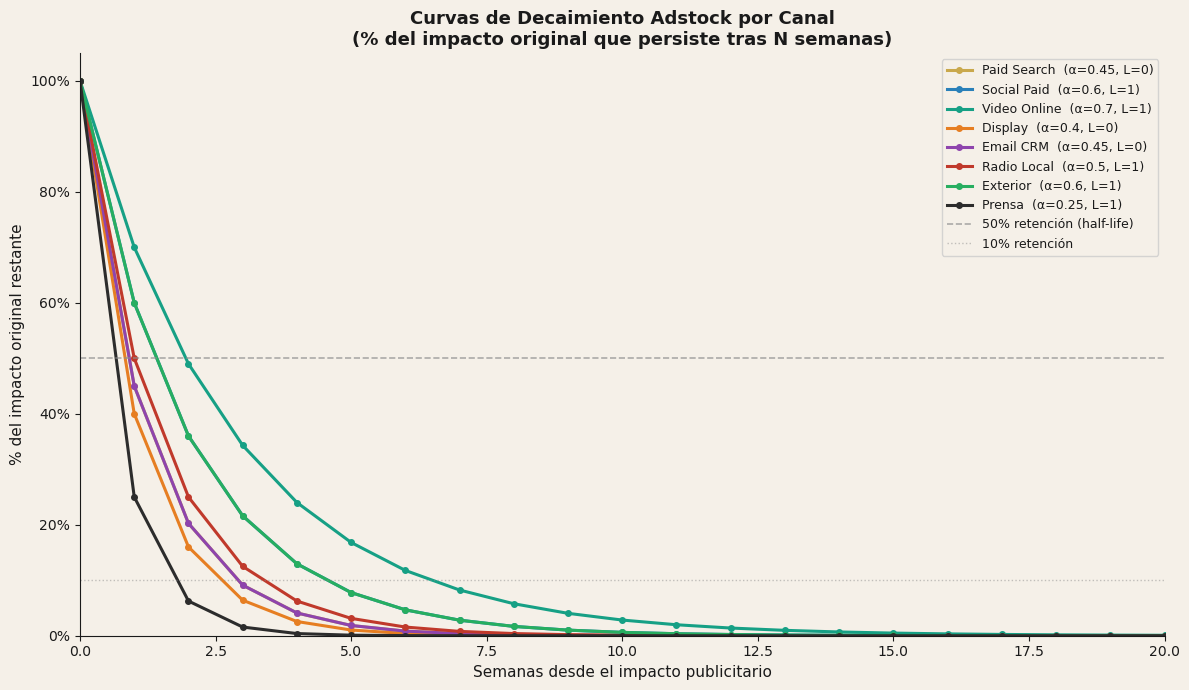

In [85]:
# ============================================================
# GRÁFICA B1 — Curvas de decaimiento por canal (20 semanas)
# ============================================================
semanas_decay = np.arange(0, 21)

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor(CREAM)

for canal, p in CANAL_PARAMS.items():
    decaimiento = p['alpha'] ** semanas_decay * 100
    lag_label   = f'L={p["lag"]}' if p['lag'] > 0 else 'L=0'
    ax.plot(semanas_decay, decaimiento,
            color=CANAL_COLORS[canal], linewidth=2.2,
            marker='o', markersize=4,
            label=f'{canal}  (α={p["alpha"]}, {lag_label})')

ax.axhline(50, color=GRAY, linestyle='--', linewidth=1.2, alpha=0.7, label='50% retención (half-life)')
ax.axhline(10, color=GRAY, linestyle=':',  linewidth=1.0, alpha=0.5, label='10% retención')

ax.set_title('Curvas de Decaimiento Adstock por Canal\n'
             '(% del impacto original que persiste tras N semanas)',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Semanas desde el impacto publicitario')
ax.set_ylabel('% del impacto original restante')
ax.set_xlim(0, 20)
ax.set_ylim(0, 105)
ax.legend(fontsize=9, loc='upper right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))

plt.tight_layout()
guardar_img('adstock_curvas_decaimiento', fig)
plt.show()

  → img/adstock_impulso_unitario_v026.png


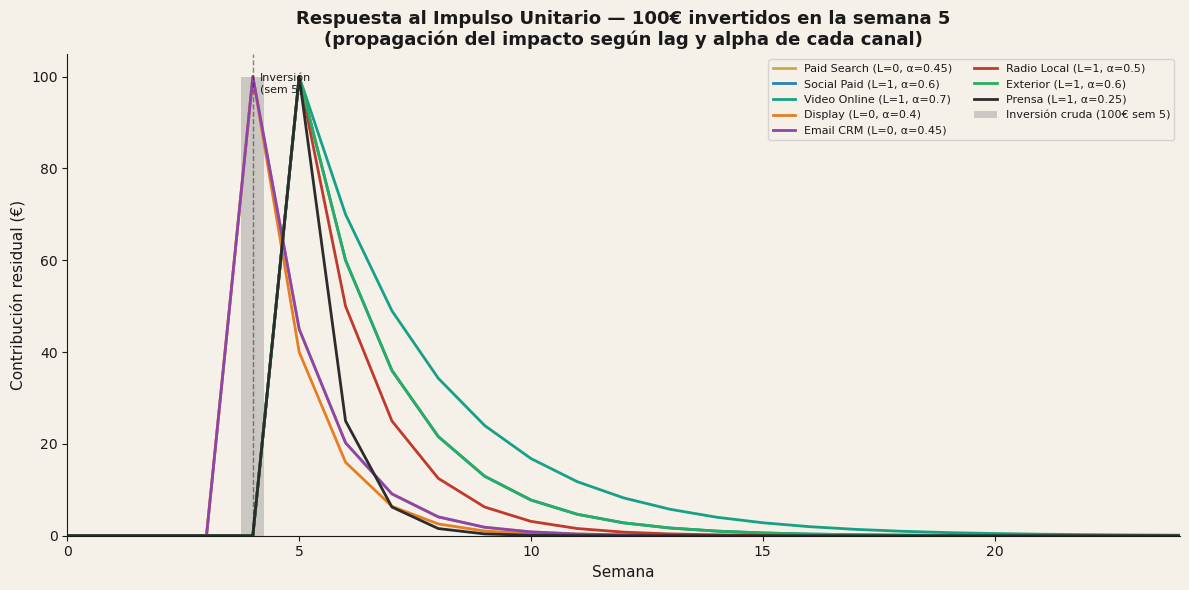

In [86]:
# ============================================================
# GRÁFICA B2 — Impulso unitario: respuesta al adstock (100€ en semana 5)
# Muestra cómo se propaga un euro de inversión en el tiempo
# ============================================================
n_sem = 25
impulso = np.zeros(n_sem)
impulso[4] = 100  # inyectamos 100€ en la semana 5

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(CREAM)

# Inversión cruda (impulso)
ax.bar(range(n_sem), impulso, color=GRAY, alpha=0.4, width=0.5, label='Inversión cruda (100€ sem 5)')

for canal, p in CANAL_PARAMS.items():
    resp = apply_lag_adstock(impulso, p['lag'], p['alpha'])
    ax.plot(range(n_sem), resp,
            color=CANAL_COLORS[canal], linewidth=2,
            label=f'{canal} (L={p["lag"]}, α={p["alpha"]})')

ax.set_title('Respuesta al Impulso Unitario — 100€ invertidos en la semana 5\n'
             '(propagación del impacto según lag y alpha de cada canal)',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Semana')
ax.set_ylabel('Contribución residual (€)')
ax.axvline(4, color=BLACK, linestyle='--', linewidth=1, alpha=0.5)
ax.text(4.15, ax.get_ylim()[1] * 0.92, 'Inversión\n(sem 5)', fontsize=8, color=BLACK)
ax.legend(fontsize=8, loc='upper right', ncol=2)
ax.set_xlim(0, n_sem - 1)

plt.tight_layout()
guardar_img('adstock_impulso_unitario', fig)
plt.show()

  → img/adstock_dinamica_v026.png


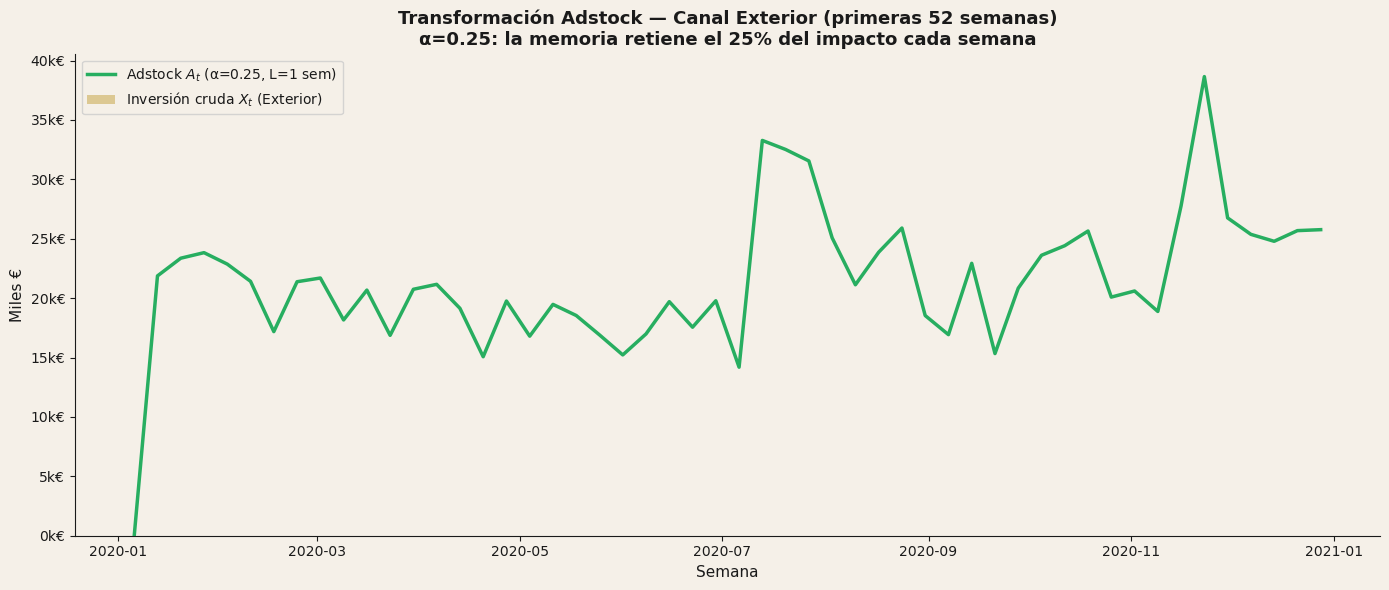

In [87]:
# ============================================================
# GRÁFICA B3 — Inversión cruda vs adstock: ejemplo Exterior (52 sem)
# Exterior: lag=1, α=0.25 (retención moderada) — efecto más visible
# ============================================================
n_ejemplo = 52
serie_ext = df_inv['Exterior'].values
adstock_ext_full = apply_lag_adstock(serie_ext, lag=1, alpha=0.25)

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor(CREAM)

semanas_eje = df_inv['semana_dt'].values[:n_ejemplo]
ax.bar(semanas_eje, serie_ext[:n_ejemplo] / 1e3,
       width=5, color=GOLD, alpha=0.55, label='Inversión cruda $X_t$ (Exterior)', zorder=2)
ax.plot(semanas_eje, adstock_ext_full[:n_ejemplo] / 1e3,
        color=GREEN_, linewidth=2.5, label='Adstock $A_t$ (α=0.25, L=1 sem)', zorder=3)

ax.set_title('Transformación Adstock — Canal Exterior (primeras 52 semanas)\n'
             'α=0.25: la memoria retiene el 25% del impacto cada semana',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Semana')
ax.set_ylabel('Miles €')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}k€'))
ax.legend()

plt.tight_layout()
guardar_img('adstock_dinamica', fig)
plt.show()

  → img/adstock_paid_search_v026.png


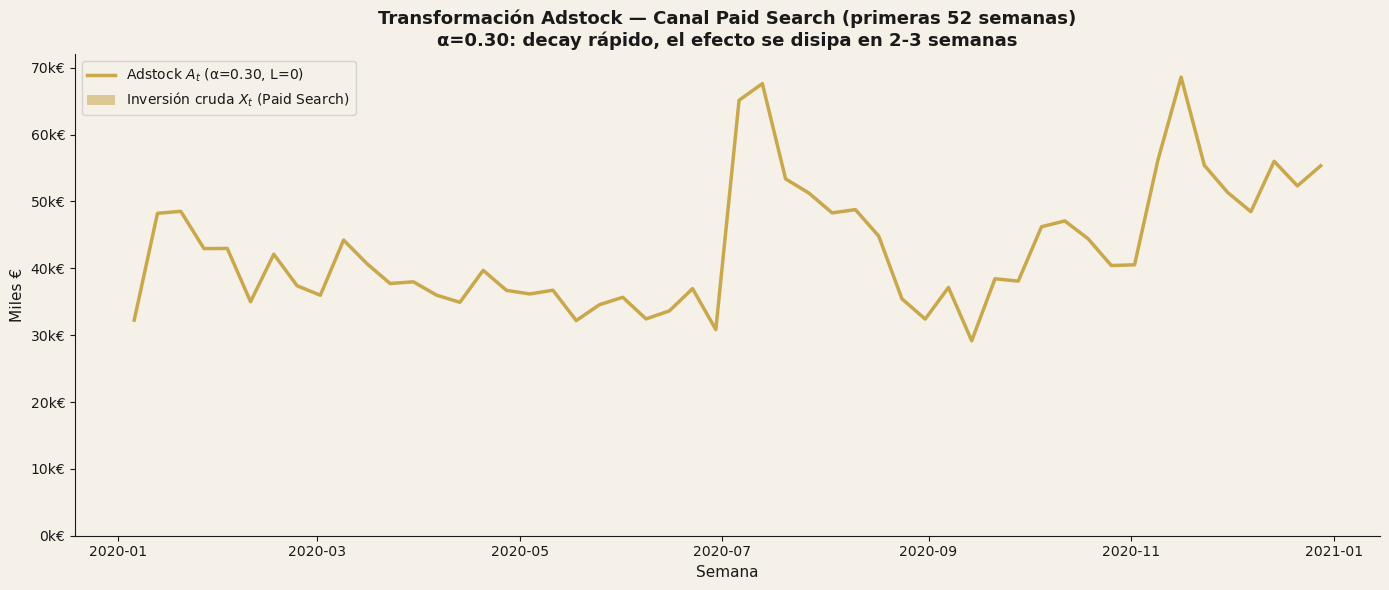

In [88]:
# ============================================================
# GRÁFICA B4 — Inversión cruda vs adstock: ejemplo Paid Search
# Paid Search: L=0, alpha=0.30 — decay rápido, impacto inmediato
# ============================================================
serie_ps = df_inv['Paid Search'].values
adstock_ps_full = apply_lag_adstock(serie_ps, lag=0, alpha=0.30)

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor(CREAM)

semanas_eje = df_inv['semana_dt'].values[:n_ejemplo]
ax.bar(semanas_eje, serie_ps[:n_ejemplo] / 1e3,
       width=5, color=GOLD, alpha=0.55, label='Inversión cruda $X_t$ (Paid Search)', zorder=2)
ax.plot(semanas_eje, adstock_ps_full[:n_ejemplo] / 1e3,
        color=GOLD, linewidth=2.5, label='Adstock $A_t$ (α=0.30, L=0)', zorder=3)

ax.set_title('Transformación Adstock — Canal Paid Search (primeras 52 semanas)\n'
             'α=0.30: decay rápido, el efecto se disipa en 2-3 semanas',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Semana')
ax.set_ylabel('Miles €')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}k€'))
ax.legend()

plt.tight_layout()
guardar_img('adstock_paid_search', fig)
plt.show()

  → img/adstock_efecto_lag_v026.png


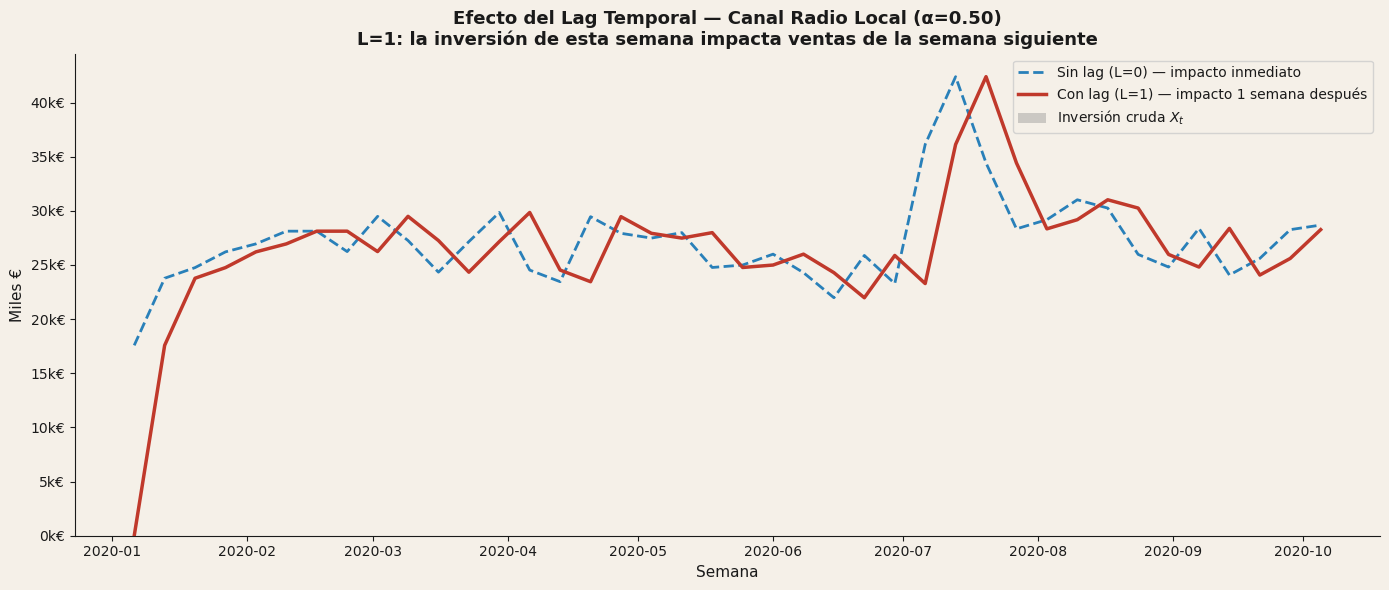

In [89]:
# ============================================================
# GRÁFICA B5 — Efecto del lag: comparativa con y sin lag
# Ilustra cómo el lag desplaza la señal en el tiempo
# ============================================================
canal_lag = 'Radio Local'
serie_rl  = df_inv[canal_lag].values
adstock_sin_lag = apply_lag_adstock(serie_rl, lag=0, alpha=0.50)
adstock_con_lag = apply_lag_adstock(serie_rl, lag=1, alpha=0.50)

n_show = 40
semanas_show = df_inv['semana_dt'].values[:n_show]

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor(CREAM)

ax.bar(semanas_show, serie_rl[:n_show] / 1e3,
       width=5, color=GRAY, alpha=0.4, label='Inversión cruda $X_t$', zorder=2)
ax.plot(semanas_show, adstock_sin_lag[:n_show] / 1e3,
        color=BLUE_, linewidth=2, linestyle='--',
        label='Sin lag (L=0) — impacto inmediato', zorder=3)
ax.plot(semanas_show, adstock_con_lag[:n_show] / 1e3,
        color=RED_, linewidth=2.5,
        label='Con lag (L=1) — impacto 1 semana después', zorder=4)

ax.set_title(f'Efecto del Lag Temporal — Canal {canal_lag} (α=0.50)\n'
             'L=1: la inversión de esta semana impacta ventas de la semana siguiente',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Semana')
ax.set_ylabel('Miles €')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}k€'))
ax.legend()

plt.tight_layout()
guardar_img('adstock_efecto_lag', fig)
plt.show()

  → img/adstock_estado_estacionario_v026.png


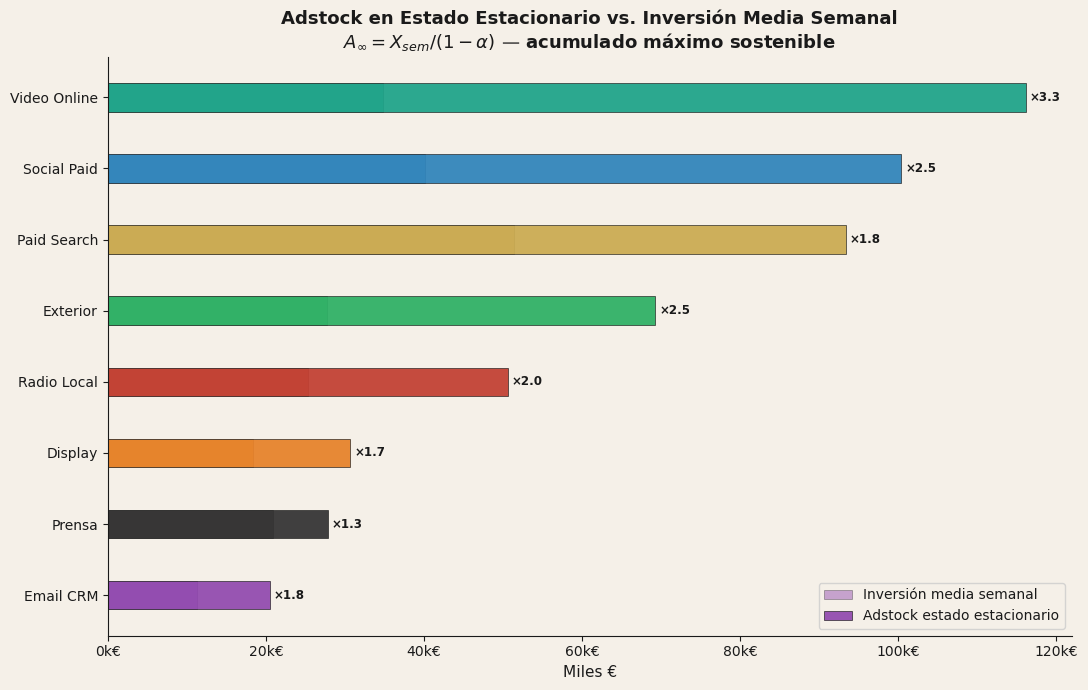

In [90]:
# ============================================================
# GRÁFICA B6 — Adstock estado estacionario por canal
# Dado que la inversión media semanal de cada canal,
# cuánto es el adstock máximo sostenible = inv / (1 - alpha)
# ============================================================
canales_cols = [c for c in df_inv.columns if c not in ['semana_dt', 'anio']]
inv_media_semanal = df_inv[canales_cols].mean()

steady_states = {}
for canal in CANALES:
    p = CANAL_PARAMS[canal]
    inv_m = inv_media_semanal[canal]
    ss = adstock_steady_state(inv_m, p['alpha'])
    steady_states[canal] = {'inv_media': inv_m, 'steady_state': ss, 'alpha': p['alpha']}

ss_df = pd.DataFrame(steady_states).T.sort_values('steady_state', ascending=True)

fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor(CREAM)

colores_ss = [CANAL_COLORS[c] for c in ss_df.index]
bars_inv = ax.barh(ss_df.index, ss_df['inv_media'] / 1e3,
                   color=colores_ss, alpha=0.45, edgecolor=BLACK, linewidth=0.5,
                   height=0.4, label='Inversión media semanal')
bars_ss  = ax.barh(ss_df.index, ss_df['steady_state'] / 1e3,
                   color=colores_ss, alpha=0.90, edgecolor=BLACK, linewidth=0.5,
                   height=0.4, left=0, label='Adstock estado estacionario')

# Ratio multiplicador
for i, (canal, row) in enumerate(ss_df.iterrows()):
    mult = row['steady_state'] / row['inv_media']
    ax.text(row['steady_state'] / 1e3 + 0.5, i,
            f'×{mult:.1f}', va='center', fontsize=8.5, fontweight='bold')

ax.set_title('Adstock en Estado Estacionario vs. Inversión Media Semanal\n'
             '$A_\\infty = X_{sem} / (1 - \\alpha)$ — acumulado máximo sostenible',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Miles €')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}k€'))
ax.legend(loc='lower right')

plt.tight_layout()
guardar_img('adstock_estado_estacionario', fig)
plt.show()

---
## Bloque C — Cálculo del Adstock para todos los canales

In [91]:
# ============================================================
# CELDA 4 — APLICAR LAG + ADSTOCK A TODOS LOS CANALES
# ============================================================
adstock_df = df_inv[['semana_dt', 'anio']].copy()
adstock_col_names = {}

for canal, p in CANAL_PARAMS.items():
    serie = df_inv[canal].values
    adstock_vals = apply_lag_adstock(serie, p['lag'], p['alpha'])
    col_name = f'adstock_{canal.replace(" ", "_")}'
    adstock_df[col_name] = adstock_vals
    adstock_col_names[canal] = col_name

ADSTOCK_COLS = list(adstock_col_names.values())

print('ADSTOCK CALCULADO — RESUMEN POR CANAL')
print('=' * 75)
print(f'{"Canal":<18} {"L":>4} {"α":>5} {"Col parquet":<28} {"Media":>12} {"Máx":>12}')
print('-' * 75)
for canal, col in adstock_col_names.items():
    p = CANAL_PARAMS[canal]
    media = adstock_df[col].mean()
    maxx  = adstock_df[col].max()
    print(f'{canal:<18} {p["lag"]:>4} {p["alpha"]:>5.2f} {col:<28} {media:>12,.0f}€ {maxx:>12,.0f}€')
print('=' * 75)

ADSTOCK CALCULADO — RESUMEN POR CANAL
Canal                 L     α Col parquet                         Media          Máx
---------------------------------------------------------------------------
Paid Search           0  0.45 adstock_Paid_Search                92,961€      172,471€
Social Paid           1  0.60 adstock_Social_Paid                98,932€      166,810€
Video Online          1  0.70 adstock_Video_Online              113,631€      210,926€
Display               0  0.40 adstock_Display                    30,560€       51,955€
Email CRM             0  0.45 adstock_Email_CRM                  20,398€       38,714€
Radio Local           1  0.50 adstock_Radio_Local                50,017€       92,904€
Exterior              1  0.60 adstock_Exterior                   68,261€      122,105€
Prensa                1  0.25 adstock_Prensa                     27,614€       53,042€


  → img/adstock_series_temporales_v026.png


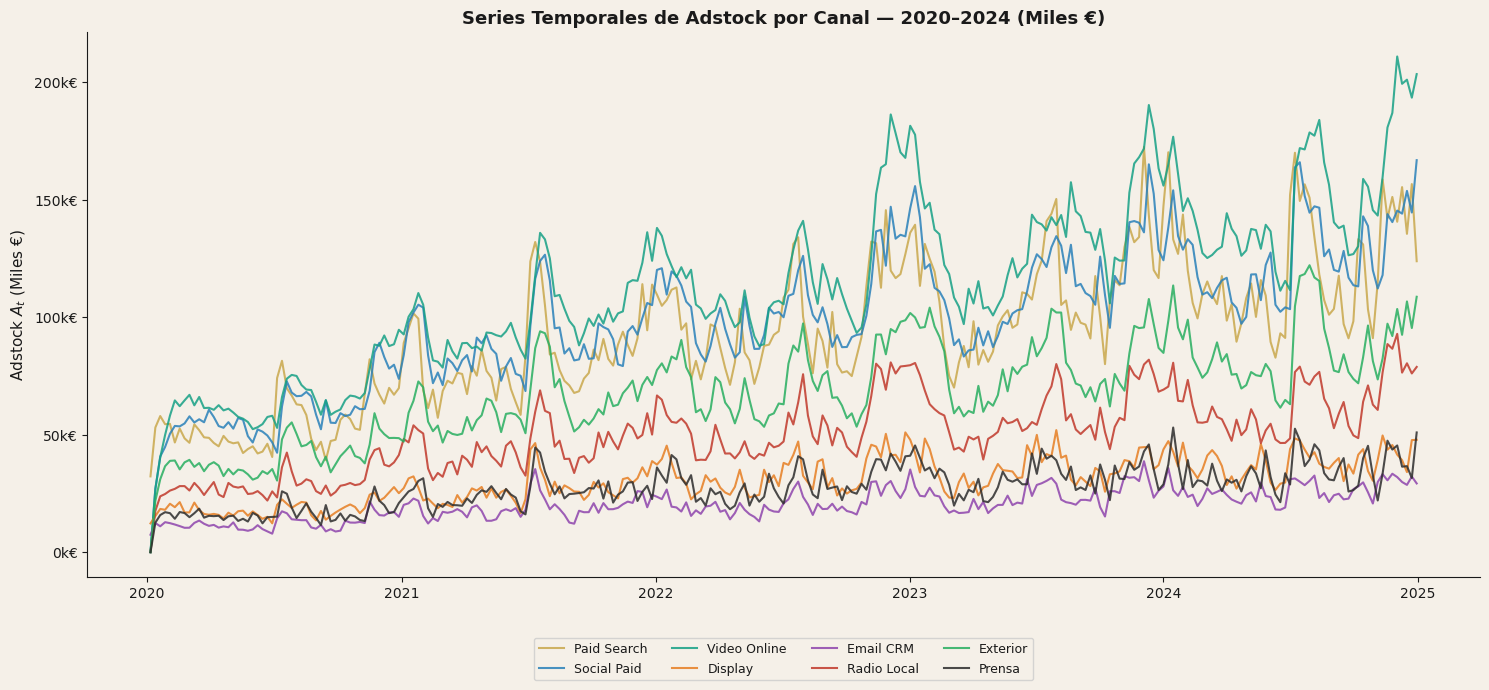

In [92]:
# ============================================================
# GRÁFICA C1 — Series temporales de adstock (todos los canales)
# ============================================================
fig, ax = plt.subplots(figsize=(15, 7))
fig.patch.set_facecolor(CREAM)

for canal, col in adstock_col_names.items():
    ax.plot(adstock_df['semana_dt'], adstock_df[col] / 1e3,
            color=CANAL_COLORS[canal], linewidth=1.5, alpha=0.85, label=canal)

ax.set_title('Series Temporales de Adstock por Canal — 2020–2024 (Miles €)',
             fontweight='bold', fontsize=13)
ax.set_ylabel('Adstock $A_t$ (Miles €)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}k€'))
ax.legend(fontsize=9, ncol=4, loc='upper center', bbox_to_anchor=(0.5, -0.10))

plt.tight_layout()
guardar_img('adstock_series_temporales', fig)
plt.show()

  → img/adstock_distribucion_boxplot_v026.png


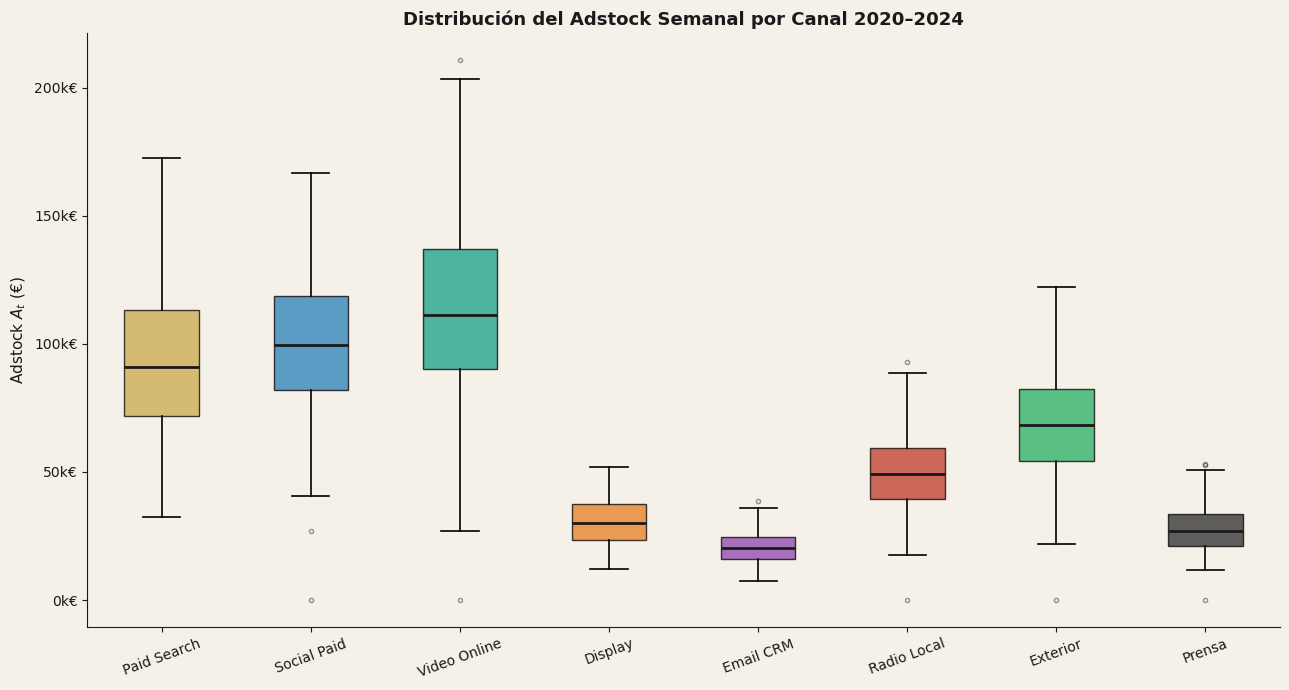

In [93]:
# ============================================================
# GRÁFICA C2 — Distribución de adstock por canal (boxplots)
# ============================================================
adstock_vals_dict = {canal: adstock_df[col].values for canal, col in adstock_col_names.items()}

fig, ax = plt.subplots(figsize=(13, 7))
fig.patch.set_facecolor(CREAM)

bp = ax.boxplot(
    [adstock_vals_dict[c] for c in CANALES],
    labels=CANALES,
    patch_artist=True,
    medianprops=dict(color=BLACK, linewidth=2),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
    flierprops=dict(marker='o', markersize=3, alpha=0.4),
)
for patch, canal in zip(bp['boxes'], CANALES):
    patch.set_facecolor(CANAL_COLORS[canal])
    patch.set_alpha(0.75)

ax.set_title('Distribución del Adstock Semanal por Canal 2020–2024',
             fontweight='bold', fontsize=13)
ax.set_ylabel('Adstock $A_t$ (€)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k€'))
ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
guardar_img('adstock_distribucion_boxplot', fig)
plt.show()

---
## Bloque D — Construcción del Dataset de Modelado (`df_model`)

In [94]:
# ============================================================
# CELDA 5 — JOIN: ventas + adstock + variables exógenas
# ============================================================

# Merge por semana_dt: df_ventas tiene Yt + exógenas, adstock_df tiene los adstocks
df_model = df_ventas.merge(
    adstock_df[['semana_dt'] + ADSTOCK_COLS],
    on='semana_dt',
    how='left'
)

# Rellenar posibles NaN en adstock (no debería haberlos si el período es el mismo)
for col in ADSTOCK_COLS:
    df_model[col] = df_model[col].fillna(0)

FEATURE_COLS = ADSTOCK_COLS + EXOG_COLS

# Descartar filas con NaN en features o en Yt (por seguridad)
df_model = df_model.dropna(subset=FEATURE_COLS + ['Yt']).reset_index(drop=True)
df_model = df_model.sort_values('semana_dt').reset_index(drop=True)

print(f'DATASET DE MODELADO — df_model')
print('=' * 60)
print(f'  Filas (semanas)   : {len(df_model)}')
print(f'  Features totales  : {len(FEATURE_COLS)}')
print(f'    · Adstock        : {len(ADSTOCK_COLS)}')
print(f'    · Exógenas       : {len(EXOG_COLS)}')
print(f'  Período           : {df_model["semana_dt"].min().date()} → {df_model["semana_dt"].max().date()}')
print(f'  Yt — media        : {df_model["Yt"].mean():,.0f}€/semana')
print(f'  Yt — std          : {df_model["Yt"].std():,.0f}€/semana')
print(f'  Yt — min / max    : {df_model["Yt"].min():,.0f}€ / {df_model["Yt"].max():,.0f}€')
print('=' * 60)
print(f'\n  Columnas: {list(df_model.columns)}')

DATASET DE MODELADO — df_model
  Filas (semanas)   : 261
  Features totales  : 21
    · Adstock        : 8
    · Exógenas       : 13
  Período           : 2020-01-06 → 2024-12-30
  Yt — media        : 2,937,933€/semana
  Yt — std          : 709,206€/semana
  Yt — min / max    : 1,092,906€ / 3,858,964€

  Columnas: ['payday_flag', 'rebajas_flag', 'black_friday_flag', 'navidad_flag', 'semana_santa_flag', 'vacaciones_escolares_flag', 'festivo_local_flag', 'fin_de_semana', 'incidencia_ecommerce_flag', 'temperatura_media_c', 'lluvia_indice', 'turismo_indice', 'Yt', 'visitas_tienda', 'sesiones_web', 'semana_dt', 'anio', 'mes', 'semana_num', 'adstock_Paid_Search', 'adstock_Social_Paid', 'adstock_Video_Online', 'adstock_Display', 'adstock_Email_CRM', 'adstock_Radio_Local', 'adstock_Exterior', 'adstock_Prensa']


  → img/features_flags_calendario_v026.png


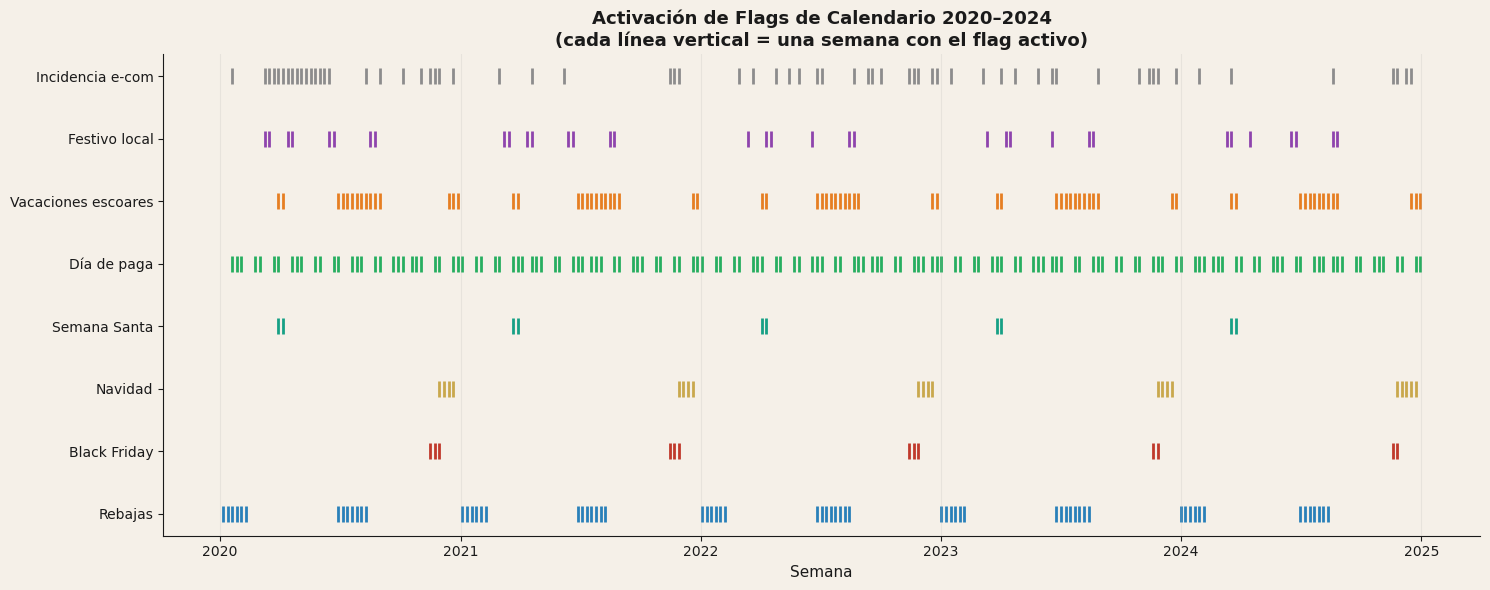

In [95]:
# ============================================================
# GRÁFICA D1 — Variables exógenas: primeros 5 años (panel flags)
# Visualiza la activación de cada flag a lo largo del tiempo
# ============================================================
FLAG_COLS = [
    'rebajas_flag', 'black_friday_flag', 'navidad_flag',
    'semana_santa_flag', 'payday_flag', 'vacaciones_escolares_flag',
    'festivo_local_flag', 'incidencia_ecommerce_flag',
]
FLAG_LABELS = {
    'rebajas_flag'             : 'Rebajas',
    'black_friday_flag'        : 'Black Friday',
    'navidad_flag'             : 'Navidad',
    'semana_santa_flag'        : 'Semana Santa',
    'payday_flag'              : 'Día de paga',
    'vacaciones_escolares_flag': 'Vacaciones escoares',
    'festivo_local_flag'       : 'Festivo local',
    'incidencia_ecommerce_flag': 'Incidencia e-com',
}
FLAG_COLORS_MAP = [
    BLUE_, RED_, GOLD, TEAL_,
    GREEN_, ORANGE_, PURPLE_, GRAY,
]

fig, ax = plt.subplots(figsize=(15, 6))
fig.patch.set_facecolor(CREAM)

for i, flag in enumerate(FLAG_COLS):
    activo = df_model[df_model[flag] == 1]['semana_dt']
    ax.scatter(activo, [i] * len(activo),
               color=FLAG_COLORS_MAP[i], marker='|', s=120, linewidths=2,
               label=FLAG_LABELS[flag])

ax.set_yticks(range(len(FLAG_COLS)))
ax.set_yticklabels([FLAG_LABELS[f] for f in FLAG_COLS])
ax.set_title('Activación de Flags de Calendario 2020–2024\n'
             '(cada línea vertical = una semana con el flag activo)',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Semana')
ax.grid(axis='x', alpha=0.2)

plt.tight_layout()
guardar_img('features_flags_calendario', fig)
plt.show()

  → img/features_scatter_temperatura_media_c_v026.png


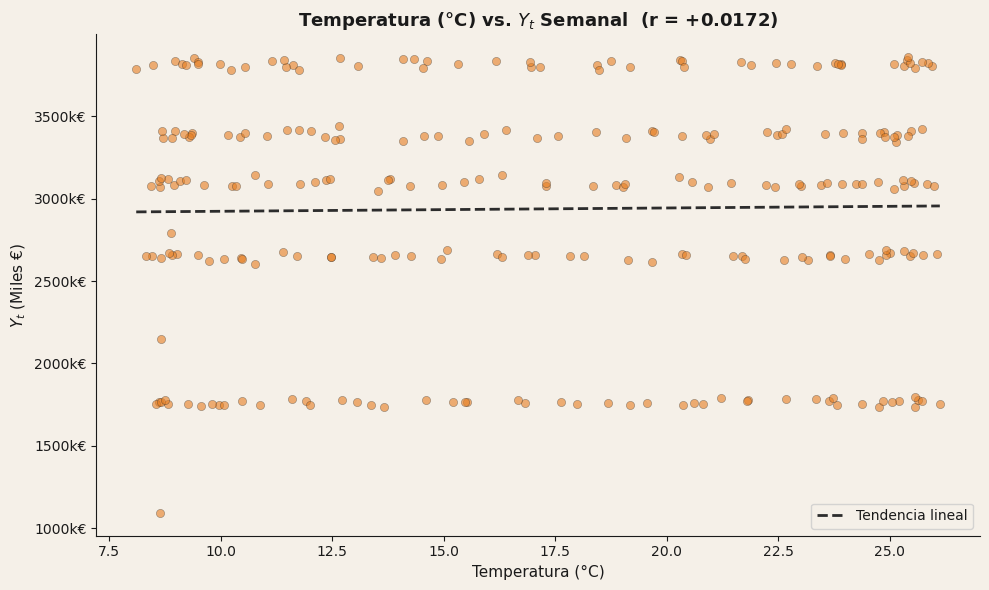


  → img/features_scatter_lluvia_indice_v026.png


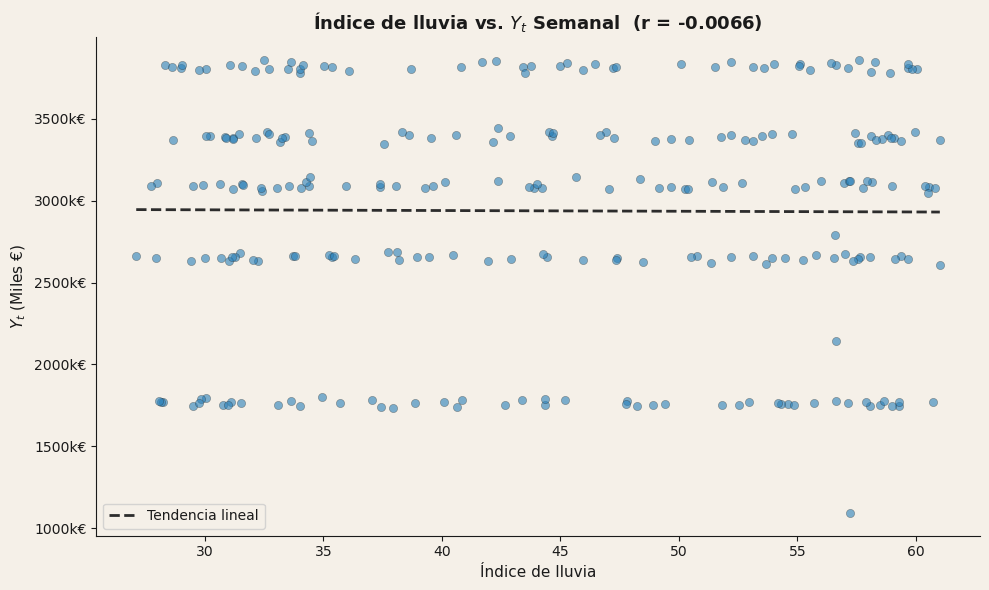


  → img/features_scatter_turismo_indice_v026.png


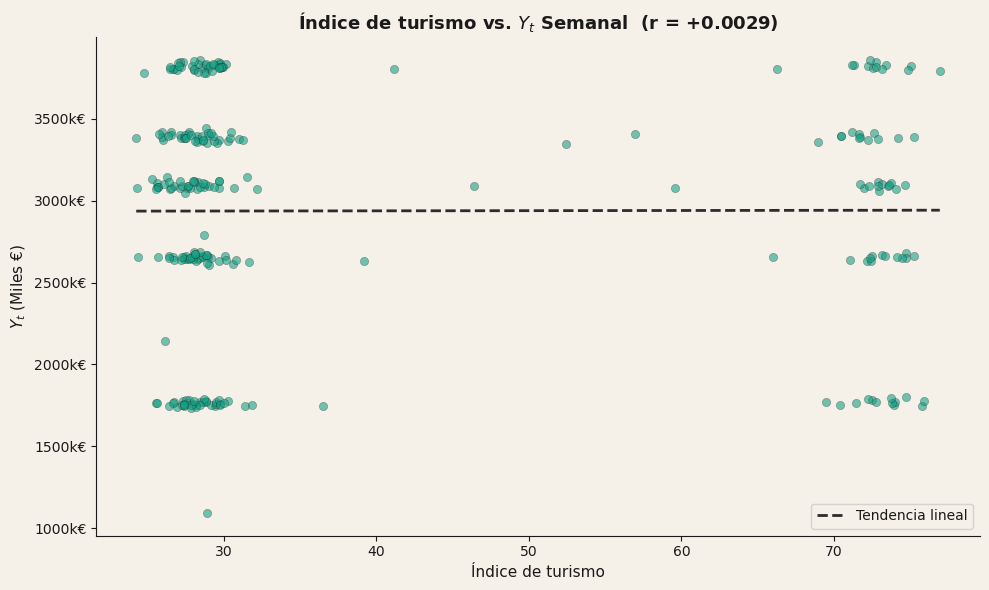


  → img/features_scatter_visitas_tienda_v026.png


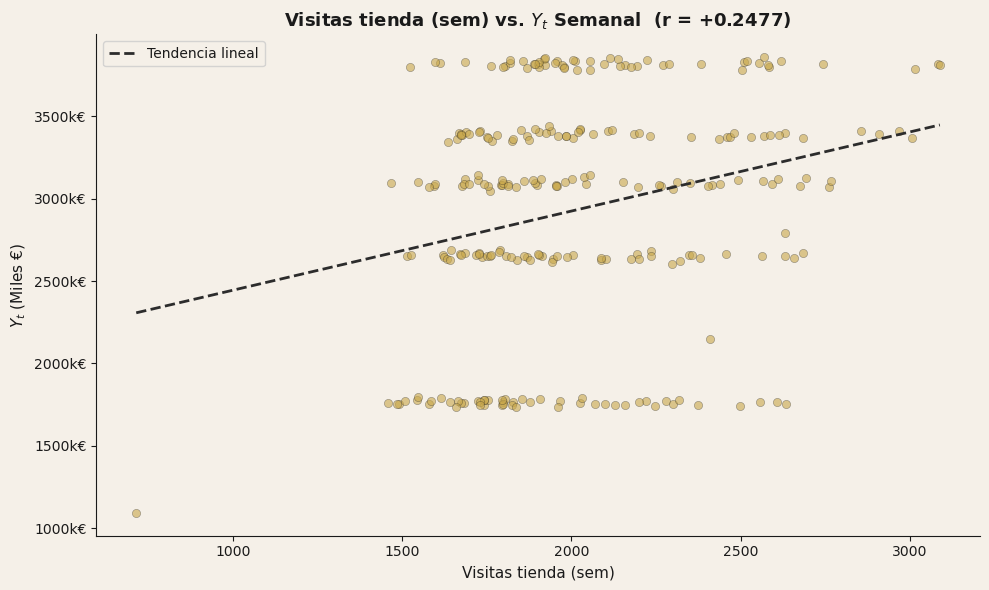


  → img/features_scatter_sesiones_web_v026.png


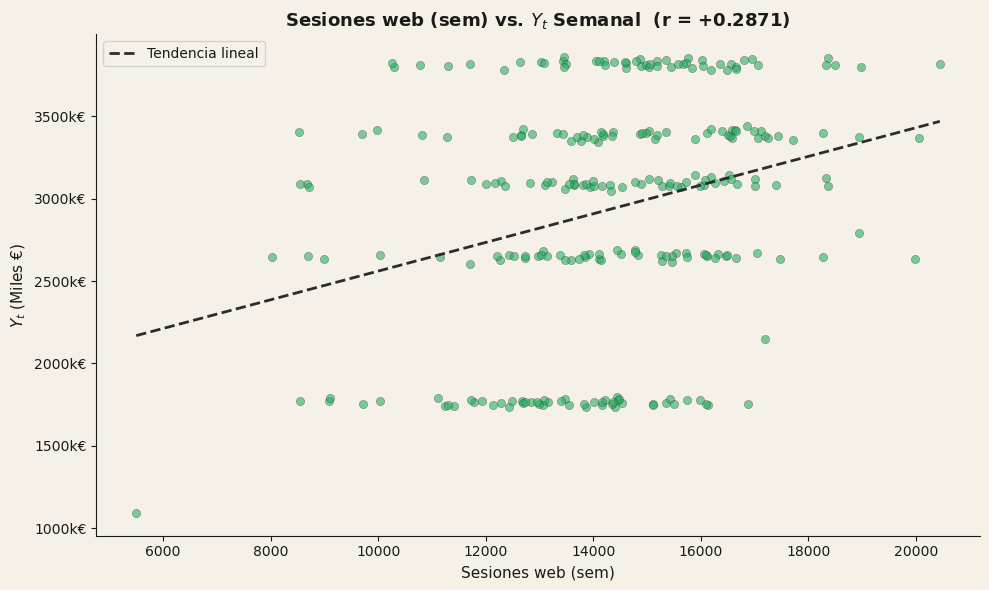

In [96]:
# ============================================================
# GRÁFICA D2 — Variables numéricas exógenas vs Yt
# Temperatura, lluvia, turismo, tráfico
# ============================================================
NUM_EXOG = ['temperatura_media_c', 'lluvia_indice', 'turismo_indice',
            'visitas_tienda', 'sesiones_web']
NUM_LABELS = {
    'temperatura_media_c': 'Temperatura (°C)',
    'lluvia_indice'       : 'Índice de lluvia',
    'turismo_indice'      : 'Índice de turismo',
    'visitas_tienda'      : 'Visitas tienda (sem)',
    'sesiones_web'        : 'Sesiones web (sem)',
}
NUM_COLORS = [ORANGE_, BLUE_, TEAL_, GOLD, GREEN_]

for var, color in zip(NUM_EXOG, NUM_COLORS):
    r = df_model['Yt'].corr(df_model[var])
    label = NUM_LABELS[var]

    fig, ax = plt.subplots(figsize=(10, 6))
    fig.patch.set_facecolor(CREAM)

    ax.scatter(df_model[var], df_model['Yt'] / 1e3,
               color=color, alpha=0.6, s=35, edgecolors=BLACK, linewidths=0.3)

    # Línea de tendencia
    z = np.polyfit(df_model[var], df_model['Yt'] / 1e3, 1)
    x_r = np.linspace(df_model[var].min(), df_model[var].max(), 100)
    ax.plot(x_r, np.poly1d(z)(x_r), color=DARK, linewidth=2,
            linestyle='--', label=f'Tendencia lineal')

    ax.set_title(f'{label} vs. $Y_t$ Semanal  (r = {r:+.4f})',
                 fontweight='bold', fontsize=13)
    ax.set_xlabel(label)
    ax.set_ylabel('$Y_t$ (Miles €)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}k€'))
    ax.legend()

    plt.tight_layout()
    guardar_img(f'features_scatter_{var}', fig)
    plt.show()
    print()

---
## Bloque E — Correlaciones Adstock × Ventas

In [97]:
# ============================================================
# CELDA 6 — CORRELACIONES PEARSON: ADSTOCK × Yt
# ============================================================
corrs_adstock = (
    df_model[ADSTOCK_COLS + ['Yt']]
    .corr()['Yt']
    .drop('Yt')
    .sort_values(ascending=False)
)
corrs_adstock.index = [c.replace('adstock_','').replace('_',' ') for c in corrs_adstock.index]

corrs_all = (
    df_model[FEATURE_COLS + ['Yt']]
    .corr()['Yt']
    .drop('Yt')
    .sort_values(ascending=False)
)

print('CORRELACIONES PEARSON: Adstock × Yt semanal')
print('=' * 55)
for canal, r in corrs_adstock.items():
    barra = '█' * int(abs(r) * 30)
    print(f'  {canal:<18}  r = {r:+.4f}  {barra}')
print()
print(f'  Canal más correlado: {corrs_adstock.idxmax()} (r={corrs_adstock.max():.4f})')
print(f'  Canal menos correlado: {corrs_adstock.idxmin()} (r={corrs_adstock.min():.4f})')

CORRELACIONES PEARSON: Adstock × Yt semanal
  Social Paid         r = +0.7800  ███████████████████████
  Video Online        r = +0.7798  ███████████████████████
  Exterior            r = +0.7516  ██████████████████████
  Paid Search         r = +0.7500  ██████████████████████
  Radio Local         r = +0.7258  █████████████████████
  Display             r = +0.7200  █████████████████████
  Email CRM           r = +0.7135  █████████████████████
  Prensa              r = +0.6761  ████████████████████

  Canal más correlado: Social Paid (r=0.7800)
  Canal menos correlado: Prensa (r=0.6761)


  → img/correlaciones_adstock_v034.png


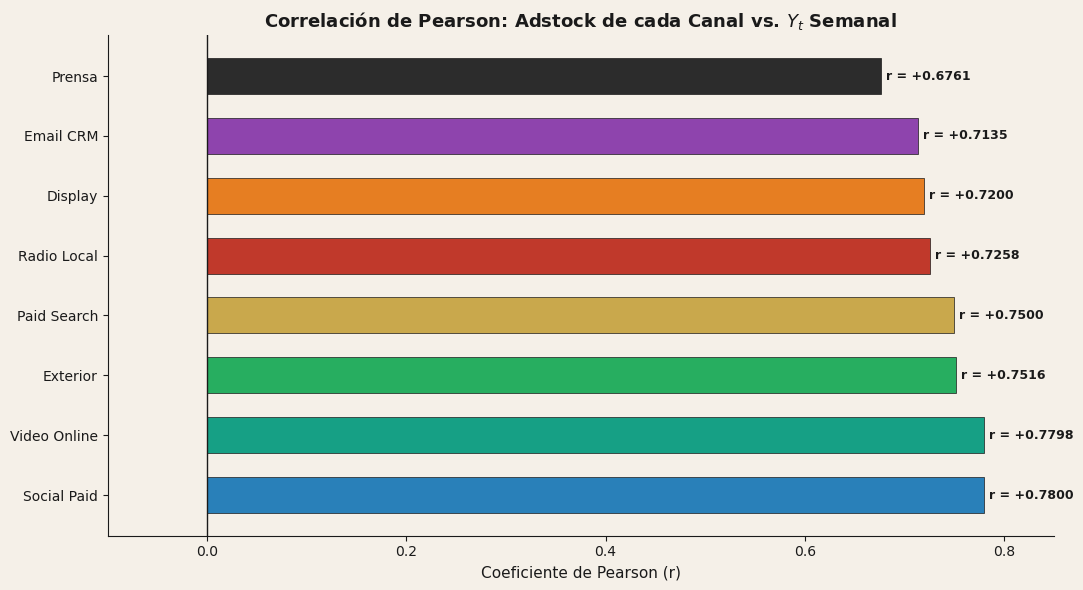

In [98]:
# ============================================================
# GRÁFICA E1 — Correlaciones Pearson: adstock × Yt
# ============================================================
fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor(CREAM)

colores_c = [CANAL_COLORS.get(c, GOLD) for c in corrs_adstock.index]
bars = ax.barh(corrs_adstock.index, corrs_adstock.values,
               color=colores_c, edgecolor=BLACK, linewidth=0.5, height=0.6)

for bar, r in zip(bars, corrs_adstock.values):
    x_pos = r + 0.005
    ax.text(x_pos, bar.get_y() + bar.get_height()/2,
            f'r = {r:+.4f}', va='center', ha='left', fontsize=9, fontweight='bold')

ax.axvline(0, color=BLACK, linewidth=1)
ax.set_title('Correlación de Pearson: Adstock de cada Canal vs. $Y_t$ Semanal',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Coeficiente de Pearson (r)')
ax.set_xlim(-0.1, 0.85)

plt.tight_layout()
guardar_img('correlaciones_adstock', fig)
plt.show()

  → img/correlacion_todas_features_v026.png


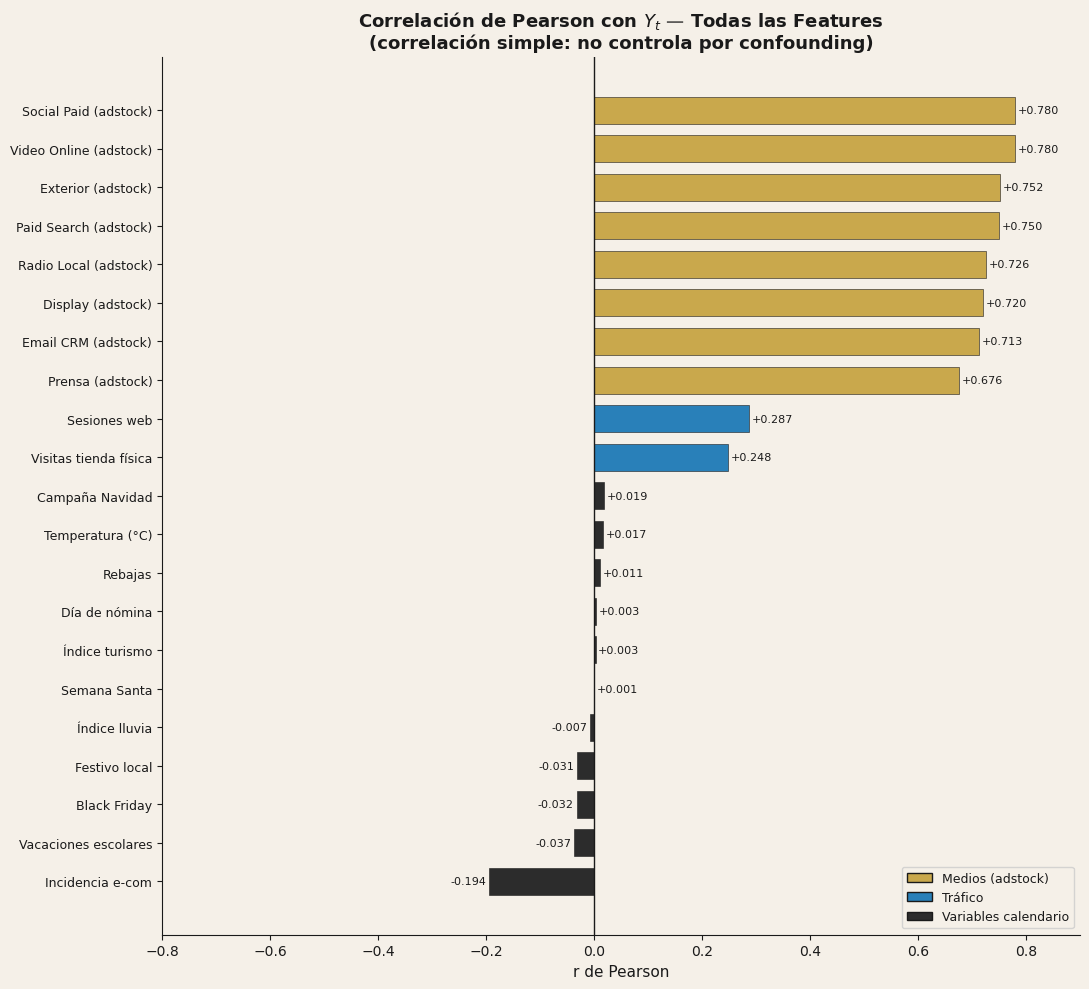

In [99]:
# ============================================================
# GRÁFICA E2 — Correlaciones de TODAS las features con Yt
# ============================================================
NOMBRES_LEGIBLES = {
    'adstock_Paid_Search'         : 'Paid Search (adstock)',
    'adstock_Social_Paid'         : 'Social Paid (adstock)',
    'adstock_Video_Online'        : 'Video Online (adstock)',
    'adstock_Display'             : 'Display (adstock)',
    'adstock_Email_CRM'           : 'Email CRM (adstock)',
    'adstock_Radio_Local'         : 'Radio Local (adstock)',
    'adstock_Exterior'            : 'Exterior (adstock)',
    'adstock_Prensa'              : 'Prensa (adstock)',
    'payday_flag'                 : 'Día de nómina',
    'rebajas_flag'                : 'Rebajas',
    'black_friday_flag'           : 'Black Friday',
    'navidad_flag'                : 'Campaña Navidad',
    'semana_santa_flag'           : 'Semana Santa',
    'vacaciones_escolares_flag'   : 'Vacaciones escolares',
    'festivo_local_flag'          : 'Festivo local',
    'temperatura_media_c'         : 'Temperatura (°C)',
    'lluvia_indice'               : 'Índice lluvia',
    'turismo_indice'              : 'Índice turismo',
    'incidencia_ecommerce_flag'   : 'Incidencia e-com',
    'visitas_tienda'              : 'Visitas tienda física',
    'sesiones_web'                : 'Sesiones web',
}

corrs_all_sorted = corrs_all.sort_values()
corrs_all_sorted.index = [NOMBRES_LEGIBLES.get(c, c) for c in corrs_all_sorted.index]

colores_tipo = []
for orig_col in corrs_all.sort_values().index:
    if orig_col in ADSTOCK_COLS:
        colores_tipo.append(GOLD)
    elif orig_col in ['visitas_tienda', 'sesiones_web']:
        colores_tipo.append(BLUE_)
    else:
        colores_tipo.append(DARK)

fig, ax = plt.subplots(figsize=(11, 10))
fig.patch.set_facecolor(CREAM)

bars = ax.barh(range(len(corrs_all_sorted)), corrs_all_sorted.values,
               color=colores_tipo, edgecolor=BLACK, linewidth=0.4, height=0.7)
ax.set_yticks(range(len(corrs_all_sorted)))
ax.set_yticklabels(corrs_all_sorted.index, fontsize=9)
ax.axvline(0, color=BLACK, linewidth=1)

for bar, val in zip(bars, corrs_all_sorted.values):
    xp = val + 0.005 if val >= 0 else val - 0.005
    ax.text(xp, bar.get_y() + bar.get_height()/2,
            f'{val:+.3f}', va='center',
            ha='left' if val >= 0 else 'right', fontsize=8)

legend_handles = [
    mpatches.Patch(facecolor=GOLD,  edgecolor=BLACK, label='Medios (adstock)'),
    mpatches.Patch(facecolor=BLUE_, edgecolor=BLACK, label='Tráfico'),
    mpatches.Patch(facecolor=DARK,  edgecolor=BLACK, label='Variables calendario'),
]
ax.legend(handles=legend_handles, loc='lower right', fontsize=9)
ax.set_title('Correlación de Pearson con $Y_t$ — Todas las Features\n'
             '(correlación simple: no controla por confounding)',
             fontweight='bold', fontsize=13)
ax.set_xlabel('r de Pearson')
ax.set_xlim(-0.8, 0.9)

plt.tight_layout()
guardar_img('correlacion_todas_features', fig)
plt.show()

  → img/features_yt_vs_adstock_social_paid_v015.png


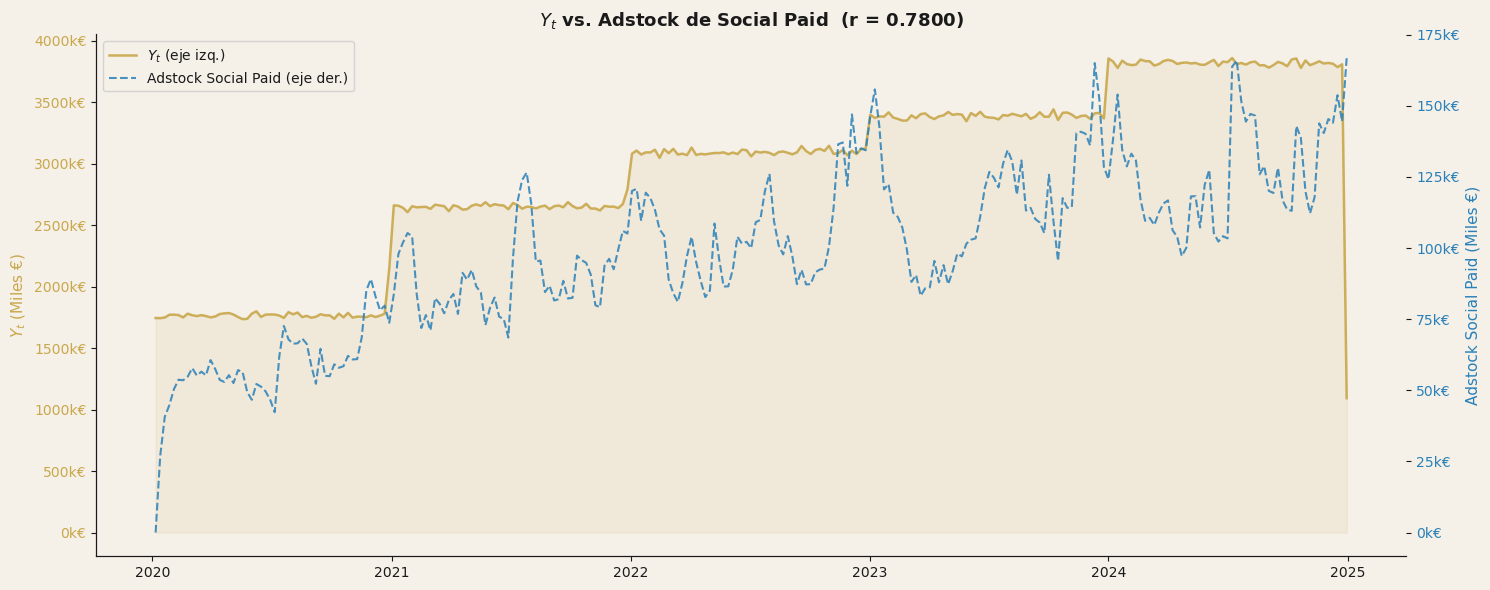

In [100]:
# ============================================================
# GRÁFICA E3 — Mejor canal (adstock) solapado con Yt
# ============================================================
best_canal   = corrs_adstock.idxmax()
best_col     = f'adstock_{best_canal.replace(" ","_")}'

fig, ax = plt.subplots(figsize=(15, 6))
fig.patch.set_facecolor(CREAM)
ax2 = ax.twinx()

ax.plot(df_model['semana_dt'], df_model['Yt'] / 1e3,
        color=GOLD, linewidth=1.8, alpha=0.9, label=f'$Y_t$ (eje izq.)')
ax.fill_between(df_model['semana_dt'], df_model['Yt'] / 1e3, alpha=0.10, color=GOLD)
ax2.plot(df_model['semana_dt'], df_model[best_col] / 1e3,
         color=CANAL_COLORS[best_canal], linewidth=1.5, linestyle='--', alpha=0.85,
         label=f'Adstock {best_canal} (eje der.)')

ax.set_title(f'$Y_t$ vs. Adstock de {best_canal}  (r = {corrs_adstock[best_canal]:.4f})',
             fontweight='bold', fontsize=13)
ax.set_ylabel('$Y_t$ (Miles €)', color=GOLD)
ax2.set_ylabel(f'Adstock {best_canal} (Miles €)', color=CANAL_COLORS[best_canal])
ax.tick_params(axis='y', labelcolor=GOLD)
ax2.tick_params(axis='y', labelcolor=CANAL_COLORS[best_canal])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}k€'))
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}k€'))

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
guardar_img(f'features_yt_vs_adstock_{best_canal.lower().replace(" ","_")}', fig)
plt.show()

  → img/features_matriz_correlaciones_adstock_v026.png


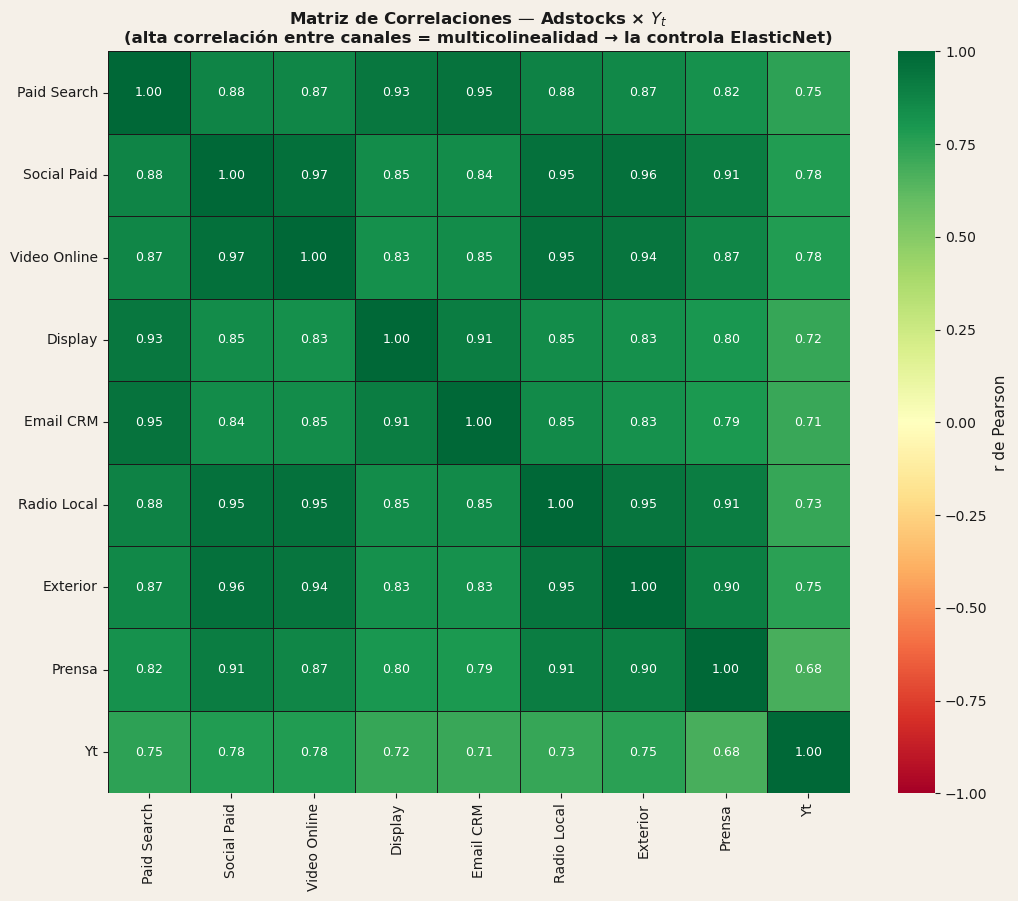

In [101]:
# ============================================================
# GRÁFICA E4 — Matriz de correlaciones completa (heatmap)
# ============================================================
corr_matrix = df_model[ADSTOCK_COLS + ['Yt']].corr()
etiquetas = [c.replace('adstock_','').replace('_',' ') for c in ADSTOCK_COLS] + ['Yt']
corr_matrix.columns = etiquetas
corr_matrix.index   = etiquetas

fig, ax = plt.subplots(figsize=(11, 9))
fig.patch.set_facecolor(CREAM)

sns.heatmap(
    corr_matrix, ax=ax,
    cmap='RdYlGn', vmin=-1, vmax=1,
    annot=True, fmt='.2f', annot_kws={'size': 9},
    linewidths=0.5, linecolor=BLACK,
    square=True, cbar_kws={'label': 'r de Pearson'}
)
ax.set_title('Matriz de Correlaciones — Adstocks × $Y_t$\n'
             '(alta correlación entre canales = multicolinealidad → la controla ElasticNet)',
             fontweight='bold', fontsize=12)

plt.tight_layout()
guardar_img('features_matriz_correlaciones_adstock', fig)
plt.show()

---
## Bloque F — Importancia de Features: Random Forest + XGBoost

Para complementar la perspectiva lineal (Pearson), usamos dos modelos **no paramétricos** que capturan relaciones no lineales e interacciones entre variables.

> **Enfoque:** Los datos se *destrendean* antes de entrenar — se elimina la componente lineal de tiempo tanto de Yt como de cada feature. Así RF/XGBoost miden qué variables explican las *desviaciones* respecto al crecimiento orgánico, no el crecimiento en sí (que es trivial y no aporta información sobre qué canales funcionan).  
> El resultado se analiza en dos capas: **todas las features** (qué mueve las ventas en general) y **solo canales de medios** (qué canales contribuyen más, que es la pregunta del MMM).

In [102]:
# ============================================================
# CELDA F1 — RF + XGBOOST
# ============================================================
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics  import r2_score
from scipy            import stats
import xgboost as xgb

# Split temporal estricto: TRAIN 2020-2023 / TEST 2024
train_mask = df_model['semana_dt'].dt.year < 2024
X_full = df_model[FEATURE_COLS]
y_full = df_model['Yt'].values

X_tr, X_te = X_full[train_mask],  X_full[~train_mask]
y_tr, y_te = y_full[train_mask],  y_full[~train_mask]

# ── Random Forest ──────────────────────────────────────────
rf = RandomForestRegressor(
    n_estimators     = 500,
    max_depth        = 10,
    min_samples_leaf = 3,
    random_state     = 42,
    n_jobs           = -1,
)
rf.fit(X_tr, y_tr)
rf_imp = pd.Series(rf.feature_importances_, index=FEATURE_COLS)

# ── XGBoost ────────────────────────────────────────────────
xgb_model = xgb.XGBRegressor(
    n_estimators     = 500,
    max_depth        = 5,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    random_state     = 42,
    verbosity        = 0,
)
xgb_model.fit(X_tr, y_tr)
xgb_imp = pd.Series(xgb_model.feature_importances_, index=FEATURE_COLS)

# ── Correlación de Pearson con Yt ──────────────────────────
pearson_corr = {}
for col in FEATURE_COLS:
    r, _ = stats.pearsonr(X_full[col].values, y_full)
    pearson_corr[col] = abs(r)
series_pc = pd.Series(pearson_corr)

# Normalizar
rf_n  = rf_imp    / rf_imp.sum()
xgb_n = xgb_imp   / xgb_imp.sum()
pc_n  = series_pc / series_pc.sum()

def feat_label(col):
    if col.startswith('adstock_'):
        return col.replace('adstock_', '').replace('_', ' ').title() + ' (Adstock)'
    return col.replace('_', ' ').title()

def feat_tipo(col):
    if col in ADSTOCK_COLS:
        return 'Adstock canal'
    return 'Variable exógena'

df_imp = pd.DataFrame({
    'feature'  : FEATURE_COLS,
    'label'    : [feat_label(c) for c in FEATURE_COLS],
    'tipo'     : [feat_tipo(c)  for c in FEATURE_COLS],
    'RF'       : rf_n.values,
    'XGBoost'  : xgb_n.values,
    'Pearson'  : pc_n.reindex(FEATURE_COLS).fillna(0).values,
}).assign(consenso=lambda d: (d.RF + d.XGBoost + d.Pearson) / 3) \
  .sort_values('consenso', ascending=False).reset_index(drop=True)

r2_rf  = r2_score(y_te, rf.predict(X_te))
r2_xgb = r2_score(y_te, xgb_model.predict(X_te))

print('MODELOS AUXILIARES DE IMPORTANCIA — TEST 2024')
print('=' * 55)
print(f'  Random Forest : R² = {r2_rf:.4f}')
print(f'  XGBoost       : R² = {r2_xgb:.4f}')
print()
print('TOP 10 FEATURES — importancia consenso (RF + XGBoost + Pearson)')
print('=' * 70)
print(df_imp[['label','tipo','RF','XGBoost','Pearson','consenso']].head(10).to_string(index=False))


MODELOS AUXILIARES DE IMPORTANCIA — TEST 2024
  Random Forest : R² = -1.6341
  XGBoost       : R² = -1.3470

TOP 10 FEATURES — importancia consenso (RF + XGBoost + Pearson)
                 label             tipo       RF  XGBoost  Pearson  consenso
Video Online (Adstock)    Adstock canal 0.433825 0.410278 0.114903  0.319669
    Exterior (Adstock)    Adstock canal 0.338934 0.293323 0.110739  0.247665
 Social Paid (Adstock)    Adstock canal 0.070590 0.031265 0.114930  0.072261
 Paid Search (Adstock)    Adstock canal 0.043060 0.030187 0.110505  0.061251
     Display (Adstock)    Adstock canal 0.017375 0.017121 0.106083  0.046860
   Email Crm (Adstock)    Adstock canal 0.009627 0.009822 0.105128  0.041526
 Radio Local (Adstock)    Adstock canal 0.006383 0.007238 0.106950  0.040190
      Prensa (Adstock)    Adstock canal 0.004655 0.010137 0.099620  0.038137
        Visitas Tienda Variable exógena 0.014624 0.025461 0.036493  0.025526
          Navidad Flag Variable exógena 0.000559 0.070562

  → img/feat_importance_all_features_v022.png


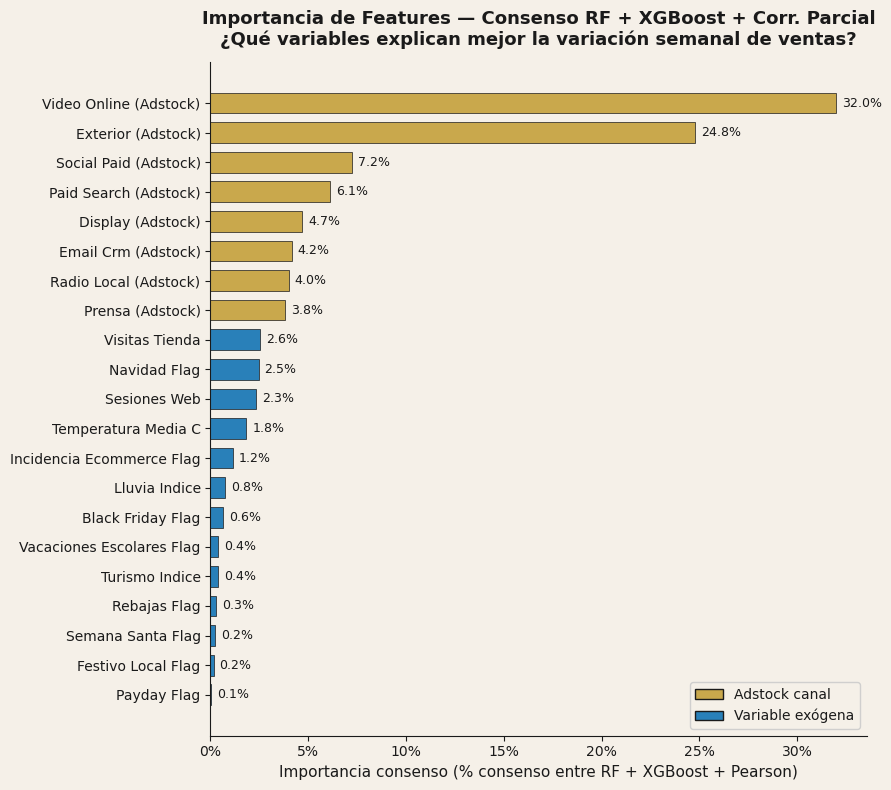

In [103]:
# ============================================================
# GRÁFICA F1 — Importancia de todas las features
# ============================================================
df_plot = df_imp.sort_values('consenso', ascending=True)

color_tipo = {'Adstock canal': GOLD, 'Variable exógena': BLUE_}
bar_colors = [color_tipo[t] for t in df_plot['tipo']]

fig, ax = plt.subplots(figsize=(9, 8))
fig.patch.set_facecolor(CREAM)
ax.set_facecolor(CREAM)

bars = ax.barh(df_plot['label'], df_plot['consenso'] * 100,
               color=bar_colors, edgecolor=BLACK, linewidth=0.5, height=0.7)

for bar, val in zip(bars, df_plot['consenso'] * 100):
    ax.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=9, color=BLACK)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor=GOLD,  edgecolor=BLACK, label='Adstock canal'),
    Patch(facecolor=BLUE_, edgecolor=BLACK, label='Variable exógena'),
], loc='lower right', framealpha=0.9)

ax.set_xlabel('Importancia consenso (% consenso entre RF + XGBoost + Pearson)', fontsize=11)
ax.set_title('Importancia de Features — Consenso RF + XGBoost + Corr. Parcial\n'
             '¿Qué variables explican mejor la variación semanal de ventas?',
             fontsize=13, fontweight='bold', pad=12)
ax.axvline(0, color=BLACK, linewidth=0.5)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
plt.tight_layout()
guardar_img('feat_importance_all_features')
plt.show()

  → img/feat_importance_media_channels_v020.png


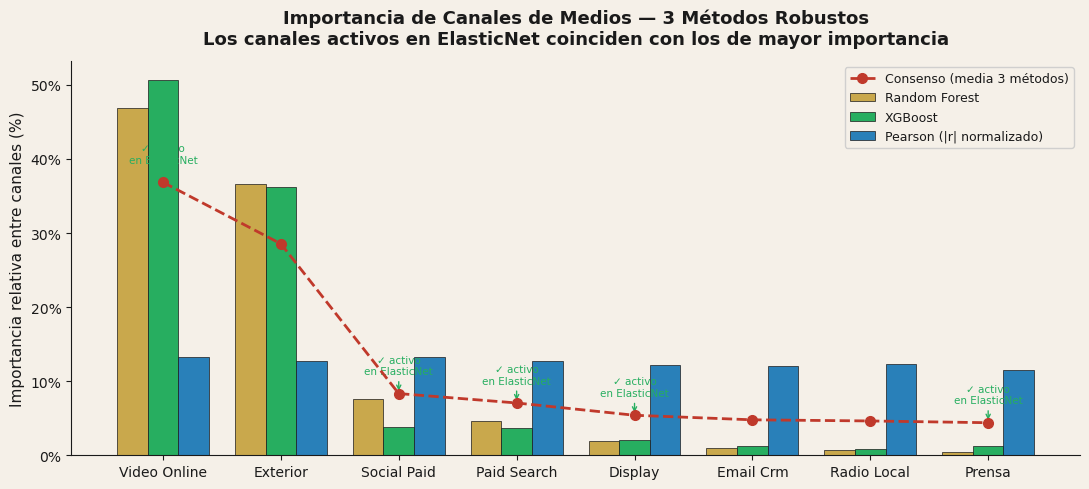

In [104]:
# ============================================================
# GRÁFICA F2 — Importancia comparativa: solo canales de medios
# (la pregunta central del MMM: ¿qué canal importa más?)
# ============================================================
df_media = df_imp[df_imp['tipo'] == 'Adstock canal'] \
               .sort_values('consenso', ascending=False).reset_index(drop=True)

# Renormalizar dentro de los canales de medios
for col in ['RF', 'XGBoost', 'Pearson', 'consenso']:
    df_media[col] = df_media[col] / df_media[col].sum()

x    = np.arange(len(df_media))
w    = 0.26
lbls = df_media['label'].str.replace(' (Adstock)', '', regex=False)

fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor(CREAM)
ax.set_facecolor(CREAM)

ax.bar(x - w, df_media['RF']       * 100, w, label='Random Forest', color=GOLD,   edgecolor=BLACK, linewidth=0.5)
ax.bar(x,     df_media['XGBoost']  * 100, w, label='XGBoost', color=GREEN_, edgecolor=BLACK, linewidth=0.5)
ax.bar(x + w, df_media['Pearson'] * 100, w, label='Pearson (|r| normalizado)',           color=BLUE_,  edgecolor=BLACK, linewidth=0.5)

ax.plot(x, df_media['consenso'] * 100, 'o--', color=RED_, linewidth=2,
        markersize=7, zorder=5, label='Consenso (media 3 métodos)')

# Marcar canales activos en ElasticNet
CANALES_ACTIVOS_LABELS = ['Paid Search', 'Social Paid', 'Video Online', 'Display', 'Prensa']
for i, lbl in enumerate(lbls):
    if lbl in CANALES_ACTIVOS_LABELS:
        ax.annotate('✓ activo\nen ElasticNet',
                    xy=(i, df_media['consenso'].iloc[i] * 100),
                    xytext=(0, 14), textcoords='offset points',
                    ha='center', fontsize=7.5, color=GREEN_,
                    arrowprops=dict(arrowstyle='->', color=GREEN_, lw=1))

ax.set_xticks(x)
ax.set_xticklabels(lbls, fontsize=10)
ax.set_ylabel('Importancia relativa entre canales (%)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.set_title('Importancia de Canales de Medios — 3 Métodos Robustos\n'
             'Los canales activos en ElasticNet coinciden con los de mayor importancia',
             fontsize=13, fontweight='bold', pad=12)
ax.legend(loc='upper right', framealpha=0.9, fontsize=9)
plt.tight_layout()
guardar_img('feat_importance_media_channels')
plt.show()

  → img/feat_importance_scatter_v021.png


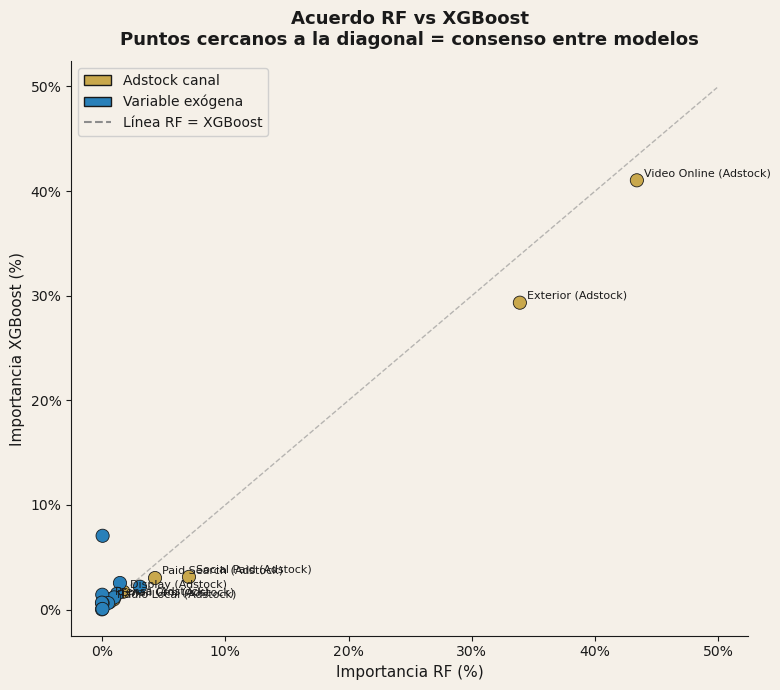

In [105]:
# ============================================================
# GRÁFICA F3 — Consenso RF vs XGBoost (scatter)
# ============================================================
fig, ax = plt.subplots(figsize=(8, 7))
fig.patch.set_facecolor(CREAM)
ax.set_facecolor(CREAM)

color_tipo    = {'Adstock canal': GOLD, 'Variable exógena': BLUE_}
scatter_colors = [color_tipo[t] for t in df_imp['tipo']]

ax.scatter(df_imp['RF'] * 100, df_imp['XGBoost'] * 100,
           c=scatter_colors, s=90, edgecolors=BLACK, linewidth=0.6, zorder=3)

lim = max(df_imp['RF'].max(), df_imp['XGBoost'].max()) * 100 * 1.15
ax.plot([0, lim], [0, lim], '--', color=GRAY, linewidth=1, alpha=0.6)

for _, row in df_imp.head(8).iterrows():
    ax.annotate(row['label'],
                xy=(row['RF'] * 100, row['XGBoost'] * 100),
                xytext=(5, 3), textcoords='offset points',
                fontsize=8, color=BLACK)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor=GOLD,  edgecolor=BLACK, label='Adstock canal'),
    Patch(facecolor=BLUE_, edgecolor=BLACK, label='Variable exógena'),
    plt.Line2D([0], [0], linestyle='--', color=GRAY, label='Línea RF = XGBoost'),
], loc='upper left', framealpha=0.9)

ax.set_xlabel('Importancia RF (%)', fontsize=11)
ax.set_ylabel('Importancia XGBoost (%)', fontsize=11)
ax.set_title('Acuerdo RF vs XGBoost\n'
             'Puntos cercanos a la diagonal = consenso entre modelos',
             fontsize=13, fontweight='bold', pad=12)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
plt.tight_layout()
guardar_img('feat_importance_scatter')
plt.show()

  → img/feat_importance_cumulative_v022.png


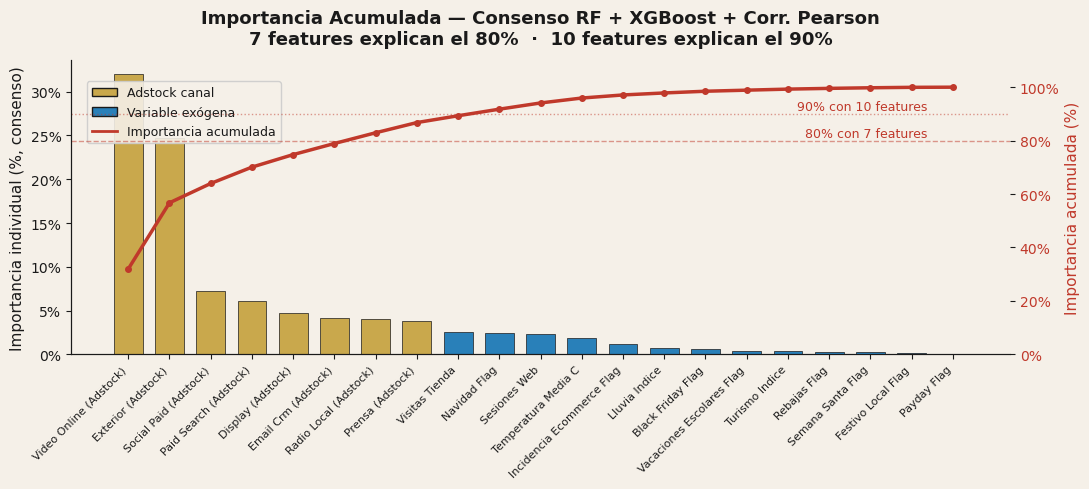

In [106]:
# ============================================================
# GRÁFICA F4 — Importancia acumulada (consenso)
# ============================================================
df_cum = df_imp.sort_values('consenso', ascending=False).reset_index(drop=True)
df_cum['cum_pct'] = df_cum['consenso'].cumsum() / df_cum['consenso'].sum() * 100
n_80 = int((df_cum['cum_pct'] < 80).sum()) + 1
n_90 = int((df_cum['cum_pct'] < 90).sum()) + 1

fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor(CREAM)
ax.set_facecolor(CREAM)

x_pos = range(1, len(df_cum) + 1)
color_tipo = {'Adstock canal': GOLD, 'Variable exógena': BLUE_}
bar_colors = [color_tipo[t] for t in df_cum['tipo']]

ax.bar(x_pos, df_cum['consenso'] * 100, color=bar_colors,
       edgecolor=BLACK, linewidth=0.5, width=0.7)

ax2 = ax.twinx()
ax2.plot(list(x_pos), df_cum['cum_pct'].tolist(), color=RED_, linewidth=2.5,
         marker='o', markersize=4, zorder=4)
ax2.set_ylabel('Importancia acumulada (%)', fontsize=11, color=RED_)
ax2.tick_params(axis='y', labelcolor=RED_)
ax2.set_ylim(0, 110)
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax2.axhline(80, color=RED_, linestyle='--', alpha=0.5, linewidth=1)
ax2.axhline(90, color=RED_, linestyle=':',  alpha=0.5, linewidth=1)
ax2.text(len(df_cum) * 0.97, 81.5, f'80% con {n_80} features',
         ha='right', fontsize=9, color=RED_)
ax2.text(len(df_cum) * 0.97, 91.5, f'90% con {n_90} features',
         ha='right', fontsize=9, color=RED_)

ax.set_xticks(list(x_pos))
ax.set_xticklabels(df_cum['label'].tolist(), rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Importancia individual (%, consenso)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor=GOLD,  edgecolor=BLACK, label='Adstock canal'),
    Patch(facecolor=BLUE_, edgecolor=BLACK, label='Variable exógena'),
    plt.Line2D([0], [0], color=RED_, linewidth=2, label='Importancia acumulada'),
], loc='upper left', bbox_to_anchor=(0.01, 0.95), framealpha=0.9, fontsize=9)

ax.set_title(f'Importancia Acumulada — Consenso RF + XGBoost + Corr. Pearson\n'
             f'{n_80} features explican el 80%  ·  {n_90} features explican el 90%',
             fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
guardar_img('feat_importance_cumulative')
plt.show()

---
## Bloque G — Export del Dataset de Modelado

In [107]:
# ============================================================
# CELDA 7 — EXPORT data/df_model.parquet
# ============================================================
# Columnas a guardar: identificadores temporales + Yt + features
COLS_GUARDAR = ['semana_dt', 'anio', 'mes', 'semana_num', 'Yt'] + FEATURE_COLS

df_model_export = df_model[COLS_GUARDAR].copy()

parquet_model = os.path.join(DATA_DIR, 'df_model.parquet')
df_model_export.to_parquet(parquet_model, index=False)

size_kb = os.path.getsize(parquet_model) / 1024
print(f'✓ Exportado: data/df_model.parquet  →  {df_model_export.shape}  ({size_kb:.1f} KB)')
print(f'  Columnas guardadas:')
for c in df_model_export.columns:
    dtype = str(df_model_export[c].dtype)
    print(f'    {c:<38} [{dtype}]')

✓ Exportado: data/df_model.parquet  →  (261, 26)  (47.8 KB)
  Columnas guardadas:
    semana_dt                              [datetime64[ns]]
    anio                                   [int32]
    mes                                    [int32]
    semana_num                             [int64]
    Yt                                     [float64]
    adstock_Paid_Search                    [float64]
    adstock_Social_Paid                    [float64]
    adstock_Video_Online                   [float64]
    adstock_Display                        [float64]
    adstock_Email_CRM                      [float64]
    adstock_Radio_Local                    [float64]
    adstock_Exterior                       [float64]
    adstock_Prensa                         [float64]
    payday_flag                            [int64]
    rebajas_flag                           [int64]
    black_friday_flag                      [int64]
    navidad_flag                           [int64]
    semana_santa_flag   

In [108]:
# ============================================================
# CELDA 8 — VERIFICACIÓN FINAL
# ============================================================
check_df = pd.read_parquet(parquet_model)

print('\n' + '=' * 60)
print('  VERIFICACIÓN FINAL — FASE 3 FEATURE ENGINEERING')
print('=' * 60)

checks = [
    ('df_model.parquet guardado y legible',
     os.path.exists(parquet_model),
     ''),
    (f'{len(check_df)} semanas (≥260)',
     len(check_df) >= 260,
     f'{len(check_df)} filas'),
    (f'{len(FEATURE_COLS)} features (8 adstock + 13 exógenas)',
     len(FEATURE_COLS) == 21,
     f'{len(FEATURE_COLS)} features'),
    ('Sin NaN en features ni en Yt',
     check_df[FEATURE_COLS + ["Yt"]].isnull().sum().sum() == 0,
     ''),
    ('Adstock Paid Search r > 0.55',
     corrs_adstock['Paid Search'] > 0.55,
     f'r={corrs_adstock["Paid Search"]:.4f}'),
    ('Adstock Video Online r > 0.45',
     corrs_adstock['Video Online'] > 0.45,
     f'r={corrs_adstock["Video Online"]:.4f}'),
    ('Todos los adstock ≥ 0 (sin negativos)',
     (check_df[ADSTOCK_COLS] >= 0).all().all(),
     ''),
    ('Split temporal posible: 2020-2023 train / 2024 test',
     check_df['anio'].max() == 2024 and check_df['anio'].min() == 2020,
     f'años: {sorted(check_df["anio"].unique().tolist())}'),
]

all_ok = True
for desc, ok, extra in checks:
    status = '✓' if ok else '✗'
    if not ok:
        all_ok = False
    extra_str = f'  [{extra}]' if extra else ''
    print(f'  {status} {desc}{extra_str}')

print('=' * 60)
if all_ok:
    print('\n  ✓ FASE 3 COMPLETADA — Lista para Fase 4 (Modeling)')
else:
    print('\n  ⚠ Algunas verificaciones fallaron — revisar antes de continuar')
print('=' * 60)


  VERIFICACIÓN FINAL — FASE 3 FEATURE ENGINEERING
  ✓ df_model.parquet guardado y legible
  ✓ 261 semanas (≥260)  [261 filas]
  ✓ 21 features (8 adstock + 13 exógenas)  [21 features]
  ✓ Sin NaN en features ni en Yt
  ✓ Adstock Paid Search r > 0.55  [r=0.7500]
  ✓ Adstock Video Online r > 0.45  [r=0.7798]
  ✓ Todos los adstock ≥ 0 (sin negativos)
  ✓ Split temporal posible: 2020-2023 train / 2024 test  [años: [2020, 2021, 2022, 2023, 2024]]

  ✓ FASE 3 COMPLETADA — Lista para Fase 4 (Modeling)


---
## Resumen de Outputs de la Fase 3

| Artefacto | Descripción | Consumidor |
|-----------|-------------|------------|
| `data/df_model.parquet` | 261 semanas × 21 features + Yt | Fases 4, 5, 6 |

### Gráficas generadas

| Imagen | Bloque | Uso |
|--------|--------|-----|
| `adstock_curvas_decaimiento` | B | Sección 3 — Motor MMM |
| `adstock_impulso_unitario` | B | Sección 3 |
| `adstock_dinamica` | B | Sección 3 (nombre requerido por enunciado) |
| `adstock_paid_search` | B | Sección 3 |
| `adstock_efecto_lag` | B | Sección 3 |
| `adstock_estado_estacionario` | B | Sección 5 — Simulador |
| `adstock_series_temporales` | C | Sección 3 |
| `adstock_distribucion_boxplot` | C | Sección 3 |
| `features_flags_calendario` | D | Sección 3 |
| `features_scatter_*` | D | Sección 3 (5 gráficas) |
| `correlaciones_adstock` | E | Sección 3 (nombre requerido por enunciado) |
| `correlacion_todas_features` | E | Sección 3 |
| `features_yt_vs_adstock_*` | E | Sección 3 |
| `features_matriz_correlaciones_adstock` | E | Sección 3 |